# EDA (recovered)

This notebook was automatically created from docs/EDA.py. Split the large code cell into multiple cells for step-by-step EDA.

In [110]:
# Cell 1: Imports + setup
%matplotlib inline

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# Plot styling
sns.set(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)

# Paths
ROOT = Path("..")  # project root
DATA_DIR = ROOT / "data"
CLEAN_PATH = DATA_DIR / "ola_cleaned.csv"

# Load dataset
df = pd.read_csv(CLEAN_PATH, parse_dates=["Datetime"])
print("Loaded CLEANED dataset:", df.shape)
display(df.head(2))


Loaded CLEANED dataset: (103024, 23)


,Date,Booking_ID,Booking_Status,Customer_ID,Vehicle_Type,Pickup_Location,Drop_Location,V_TAT,C_TAT,Canceled_Rides_by_Customer,...,Booking_Value,Payment_Method,Ride_Distance,Driver_Ratings,Customer_Rating,Datetime,ride_hour,ride_duration,is_peak,day_of_week
0,2024-07-26 14:00:00,CNR7153255142,Canceled By Driver,CID713523,Prime Sedan,Tumkur Road,RT Nagar,NaN,NaN,NaN,...,444,NaN,0,NaN,NaN,2024-07-26 14:00:00,14,NaN,0,Friday
1,2024-07-25 22:20:00,CNR2940424040,Success,CID225428,Bike,Magadi Road,Varthur,203.0,30.0,NaN,...,158,Cash,13,4.1,4.0,2024-07-25 22:20:00,22,233.0,0,Thursday


In [111]:
# Cell 2: Derived features
df["ride_hour"] = df["Datetime"].dt.hour

# Ride duration
v = df.get("V_TAT", pd.Series(np.nan, index=df.index))
c = df.get("C_TAT", pd.Series(np.nan, index=df.index))
merged = v.fillna(0) + c.fillna(0)
both_missing = v.isna() & c.isna()
df["ride_duration"] = merged
df.loc[both_missing, "ride_duration"] = np.nan

# Peak hours flag
def _is_peak(h):
    try:
        return 1 if (7 <= int(h) <= 10) or (17 <= int(h) <= 20) else 0
    except Exception:
        return 0

df["is_peak"] = df["ride_hour"].apply(_is_peak)

print("Derived features added ✅")
df[["ride_hour","ride_duration","is_peak"]].head()


Derived features added ✅


,ride_hour,ride_duration,is_peak
0,14,NaN,0
1,22,233.0,0
2,19,368.0,1
3,3,NaN,0
4,9,332.0,1


In [112]:
# ------Cleaning ----------
import numpy as np

# Paths (adjust if your notebook location differs)
full_path = DATA_DIR / "ola_full.csv"   # you earlier defined DATA_DIR = Path("..") etc.
clean_path = DATA_DIR / "ola_cleaned.csv"

# 1) Load (no deprecated arg)
print("Loading FULL dataset")
df = pd.read_csv(full_path, engine="python", on_bad_lines="skip")
print("Loaded FULL dataset\nShape:", df.shape)
print(df.columns.tolist())

# 2) Normalize column names and replace textual nulls
df.columns = [str(c).strip().replace("\ufeff", "").rstrip(",") for c in df.columns]
df = df.replace({"null": np.nan, "NULL": np.nan, "None": np.nan, "NaN": np.nan, "": np.nan})

# 3) Drop trailing / garbage columns (Unnamed or '#NAME?'-only)
cols_to_drop = []
# drop explicit trailing unnamed
if any(col.lower().startswith("unnamed") for col in df.columns):
    cols_to_drop += [col for col in df.columns if col.lower().startswith("unnamed")]
# drop Vehicle Images if present (not needed)
if "Vehicle Images" in df.columns:
    cols_to_drop.append("Vehicle Images")
# drop columns that only contain '#NAME?' or are entirely null
for col in df.columns:
    nonnull = df[col].dropna().astype(str).str.strip()
    if not nonnull.empty and all(v.upper().startswith("#NAME") for v in nonnull.unique()):
        cols_to_drop.append(col)

cols_to_drop = list(dict.fromkeys(cols_to_drop))  # dedupe
if cols_to_drop:
    print("Dropping columns:", cols_to_drop)
    df = df.drop(columns=cols_to_drop, errors="ignore")

# 4) Parse Datetime: Date already contains datetime so parse Date only
if "Date" in df.columns:
    df["Datetime"] = pd.to_datetime(df["Date"].astype(str).str.strip(), errors="coerce")
    print("Datetime nulls after parsing Date directly:", df["Datetime"].isna().sum())
else:
    # try building from Date+Time as fallback
    if ("Date" in df.columns) and ("Time" in df.columns):
        df["Datetime"] = pd.to_datetime(
            df["Date"].astype(str).str.strip() + " " + df["Time"].astype(str).str.strip(),
            errors="coerce"
        )
        print("Datetime nulls after Date+Time fallback:", df["Datetime"].isna().sum())
    else:
        df["Datetime"] = pd.NaT
        print("No Date/Time columns found — Datetime created as NaT")

# 5) (Optional) drop the redundant Time column now that Datetime exists
if "Time" in df.columns:
    df = df.drop(columns=["Time"], errors="ignore")

# 6) Normalize text columns
if "Booking_Status" in df.columns:
    df["Booking_Status"] = df["Booking_Status"].astype(str).str.strip().str.title().replace({"Nan": np.nan})
for col in ["Customer_ID", "Booking_ID", "Vehicle_Type", "Payment_Method", "Pickup_Location", "Drop_Location",
            "Canceled_Rides_by_Customer", "Canceled_Rides_by_Driver", "Incomplete_Rides", "Incomplete_Rides_Reason"]:
    if col in df.columns:
        df[col] = df[col].astype(str).str.strip().replace({"nan": np.nan, "None": np.nan})

# 7) Numeric coercion
num_cols = ['Booking_Value','Ride_Distance','Driver_Ratings','Customer_Rating','V_TAT','C_TAT']
for col in num_cols:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col].astype(str).str.replace(r"[^0-9.\-]", "", regex=True), errors='coerce')

# 8) Final shape and a quick sanity print
print("After cleaning shape:", df.shape)
print(df.dtypes.loc[[c for c in df.columns if c in ['Datetime'] + num_cols]].to_string())

# 9) Save cleaned CSV for Streamlit & future reuse
try:
    df.to_csv(clean_path, index=False)
    print("Saved cleaned dataset to:", clean_path)
except Exception as e:
    print("Could not save cleaned CSV:", e)



Loading FULL dataset
Loaded FULL dataset
Shape: (103024, 21)
['Date', 'Time', 'Booking_ID', 'Booking_Status', 'Customer_ID', 'Vehicle_Type', 'Pickup_Location', 'Drop_Location', 'V_TAT', 'C_TAT', 'Canceled_Rides_by_Customer', 'Canceled_Rides_by_Driver', 'Incomplete_Rides', 'Incomplete_Rides_Reason', 'Booking_Value', 'Payment_Method', 'Ride_Distance', 'Driver_Ratings', 'Customer_Rating', 'Vehicle Images', 'Unnamed: 20']
Dropping columns: ['Unnamed: 20', 'Vehicle Images']
Datetime nulls after parsing Date directly: 0
After cleaning shape: (103024, 19)
V_TAT                     float64
C_TAT                     float64
Booking_Value               int64
Ride_Distance               int64
Driver_Ratings            float64
Customer_Rating           float64
Datetime           datetime64[ns]
Saved cleaned dataset to: ..\data\ola_cleaned.csv


In [113]:
len(df), df["Datetime"].isna().sum(), df.columns.tolist()

(103024,
 np.int64(0),
 ['Date',
  'Booking_ID',
  'Booking_Status',
  'Customer_ID',
  'Vehicle_Type',
  'Pickup_Location',
  'Drop_Location',
  'V_TAT',
  'C_TAT',
  'Canceled_Rides_by_Customer',
  'Canceled_Rides_by_Driver',
  'Incomplete_Rides',
  'Incomplete_Rides_Reason',
  'Booking_Value',
  'Payment_Method',
  'Ride_Distance',
  'Driver_Ratings',
  'Customer_Rating',
  'Datetime'])

In [114]:
# Quick checks
print("\nBooking status distribution:\n", df['Booking_Status'].value_counts(dropna=False).head())
if 'Payment_Method' in df.columns:
    print("\nPayment method distribution:\n", df['Payment_Method'].value_counts().head())
if 'Vehicle_Type' in df.columns:
    print("\nTop vehicle types:\n", df['Vehicle_Type'].value_counts().head())

# Save cleaned csv
df.to_csv("../data/ola_cleaned.csv", index=False)
print("\nSaved cleaned data to ../data/ola_cleaned.csv")


Booking status distribution:
 Booking_Status
Success                 63967
Canceled By Driver      18434
Canceled By Customer    10499
Driver Not Found        10124
Name: count, dtype: int64

Payment method distribution:
 Payment_Method
Cash           35022
UPI            25881
Credit Card     2435
Debit Card       629
Name: count, dtype: int64

Top vehicle types:
 Vehicle_Type
Prime Sedan    14877
eBike          14816
Auto           14755
Prime Plus     14707
Bike           14662
Name: count, dtype: int64

Saved cleaned data to ../data/ola_cleaned.csv


# EDA: Exploratory Data Analysis & Visualizations

This notebook performs exploratory data analysis on the cleaned Ola rides dataset.
It documents checks, visualizations and outputs used for the Streamlit dashboard.

**Contents**
- Quick descriptive stats
- Booking status & cancellations
- Time series (daily & hourly)
- Payment & revenue analysis
- Vehicle type & distance analysis
- Ratings analysis (driver & customer)
- Top customers by booking value
- Save cleaned dataset & aggregates for Streamlit


In [115]:
# CELL 1 — Fix aggregates path and create directories safely
import os
from pathlib import Path

ROOT = Path("..")             # docs/ is current folder, repo root is ..
DATA_DIR = ROOT / "data"
AGG_DIR = DATA_DIR / "aggregates"
FIG_DIR = Path("docs") / "figures"

# If a file exists where aggregates folder should be, remove it (move if you prefer)
if AGG_DIR.exists() and not AGG_DIR.is_dir():
    print("Found a file at", AGG_DIR, " — removing it so we can create a folder.")
    os.remove(AGG_DIR)

# Create directories (idempotent)
AGG_DIR.mkdir(parents=True, exist_ok=True)
FIG_DIR.mkdir(parents=True, exist_ok=True)

print("Using aggregate folder:", AGG_DIR.resolve())
print("Using figures folder:", FIG_DIR.resolve())
# CELL 2 — Imports, plotting inline, options
%matplotlib inline

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

sns.set(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)

ROOT = Path("..")
DATA_DIR = ROOT / "data"
CLEAN_PATH = DATA_DIR / "ola_cleaned.csv"
FIG_DIR = Path("docs") / "figures"
AGG_DIR = DATA_DIR / "aggregates"

print("Imports ready. CLEAN_PATH:", CLEAN_PATH)


Using aggregate folder: D:\DA Projects\ola-ride-insights\data\aggregates
Using figures folder: D:\DA Projects\ola-ride-insights\docs\docs\figures
Imports ready. CLEAN_PATH: ..\data\ola_cleaned.csv


## Load cleaned dataset

We expect `docs/clean_data.py` or earlier cells to have produced `data/ola_cleaned.csv`.  
If not present, you can load `ola_full.csv` or `ola_sample.csv` directly (but prefer using the cleaned file).


In [116]:
# CELL 3 — Load cleaned CSV (must exist after your cleaning step)
if CLEAN_PATH.exists():
    df = pd.read_csv(CLEAN_PATH, parse_dates=["Datetime"])
    print("Loaded CLEANED:", CLEAN_PATH, "rows:", len(df))
else:
    raise FileNotFoundError(f"Cleaned file not found at {CLEAN_PATH}. Run the cleaning cell to produce 'ola_cleaned.csv' first.")
# Quick peek
display(df.head(2))
print(df.shape)


Loaded CLEANED: ..\data\ola_cleaned.csv rows: 103024


,Date,Booking_ID,Booking_Status,Customer_ID,Vehicle_Type,Pickup_Location,Drop_Location,V_TAT,C_TAT,Canceled_Rides_by_Customer,Canceled_Rides_by_Driver,Incomplete_Rides,Incomplete_Rides_Reason,Booking_Value,Payment_Method,Ride_Distance,Driver_Ratings,Customer_Rating,Datetime
0,2024-07-26 14:00:00,CNR7153255142,Canceled By Driver,CID713523,Prime Sedan,Tumkur Road,RT Nagar,NaN,NaN,NaN,Personal & Car related issue,NaN,NaN,444,NaN,0,NaN,NaN,2024-07-26 14:00:00
1,2024-07-25 22:20:00,CNR2940424040,Success,CID225428,Bike,Magadi Road,Varthur,203.0,30.0,NaN,NaN,No,NaN,158,Cash,13,4.1,4.0,2024-07-25 22:20:00


(103024, 19)


## 🔍 Missing Value Analysis

The dataset contains several columns with `NaN` values.  
These are **not necessarily errors** — they often indicate that a particular attribute is not applicable for the ride:

- **`V_TAT`, `C_TAT`** → Trip times are only recorded for completed rides.  
- **`Canceled_Rides_by_Customer`, `Canceled_Rides_by_Driver`** → Mutually exclusive; filled only when a ride is canceled.  
- **`Incomplete_Rides`, `Incomplete_Rides_Reason`** → Filled only when a ride is incomplete.  
- **`Driver_Ratings`, `Customer_Rating`** → Ratings exist only for successful rides.  

Thus, `NaN` values are meaningful and should be carefully interpreted rather than blindly imputed.


# % missing values per column
missing_pct = (df.isna().mean() * 100).sort_values(ascending=False)

plt.figure(figsize=(10,5))
sns.barplot(x=missing_pct.index, y=missing_pct.values, color="salmon")
plt.xticks(rotation=75)
plt.title("Percentage of Missing Values per Column")
plt.ylabel("% Missing")
plt.show()

missing_pct.head(10)


# Treat Driver_Ratings NaN as "No Rating"
ratings_dist = df['Driver_Ratings'].fillna("No Rating").value_counts()

plt.figure(figsize=(6,4))
sns.barplot(x=ratings_dist.index.astype(str), y=ratings_dist.values, palette="Blues")
plt.title("Driver Ratings (including missing as 'No Rating')")
plt.ylabel("Count")
plt.show()


### Key Insights from Missing Value Analysis
- **High missingness in `Canceled_Rides_by_*`** columns is expected because cancellations are mutually exclusive and not relevant for most rides.
- **Ratings NaNs** reflect that customers/drivers typically don’t rate canceled or incomplete rides.
- **Trip time NaNs** indicate rides that were never completed.
- Therefore, missing values are mostly *structural* (due to business logic), not data-entry errors.


### Basic checks & summary

Check column presence, missing counts, and types. Use these to identify problems early.


In [117]:
# Basic diagnostics
print("Columns:", df.columns.tolist())
print("\nMissing counts (top 20):")
print(df.isna().sum().sort_values(ascending=False).head(20))

print("\nDtypes:")
print(df.dtypes)

# Show sample rows with common bad tokens for inspection
bad_tokens = ["#NAME?", "null", "NULL", "NaN", "None", ""]
for tok in bad_tokens:
    # check first few columns for prevalence
    s = []
    for c in df.columns[:8]:
        count = df[c].astype(str).str.strip().eq(tok).sum()
        if count:
            s.append(f"{c}:{count}")
    if s:
        print(f"\nToken '{tok}' counts in first columns:", ", ".join(s))


Columns: ['Date', 'Booking_ID', 'Booking_Status', 'Customer_ID', 'Vehicle_Type', 'Pickup_Location', 'Drop_Location', 'V_TAT', 'C_TAT', 'Canceled_Rides_by_Customer', 'Canceled_Rides_by_Driver', 'Incomplete_Rides', 'Incomplete_Rides_Reason', 'Booking_Value', 'Payment_Method', 'Ride_Distance', 'Driver_Ratings', 'Customer_Rating', 'Datetime']

Missing counts (top 20):
Incomplete_Rides_Reason       99098
Canceled_Rides_by_Customer    92525
Canceled_Rides_by_Driver      84590
Customer_Rating               39057
Payment_Method                39057
Incomplete_Rides              39057
V_TAT                         39057
Driver_Ratings                39057
C_TAT                         39057
Date                              0
Booking_ID                        0
Booking_Status                    0
Vehicle_Type                      0
Pickup_Location                   0
Drop_Location                     0
Customer_ID                       0
Booking_Value                     0
Ride_Distance        

In [118]:
from pathlib import Path
fig_dir = Path("docs") / "figures"
fig_dir.mkdir(parents=True, exist_ok=True)
print("Figures will be saved to:", fig_dir.resolve())


Figures will be saved to: D:\DA Projects\ola-ride-insights\docs\docs\figures


In [119]:
from pathlib import Path
import os

AGG_DIR = Path("../data/aggregates")

# If a file exists at this path, delete or rename it
if AGG_DIR.exists() and not AGG_DIR.is_dir():
    os.remove(AGG_DIR)

# Now safely create the directory
AGG_DIR.mkdir(parents=True, exist_ok=True)


### Booking Status Distribution

Why: Understand overall success vs cancellation mix. This helps measure service reliability and baseline cancellation rate.


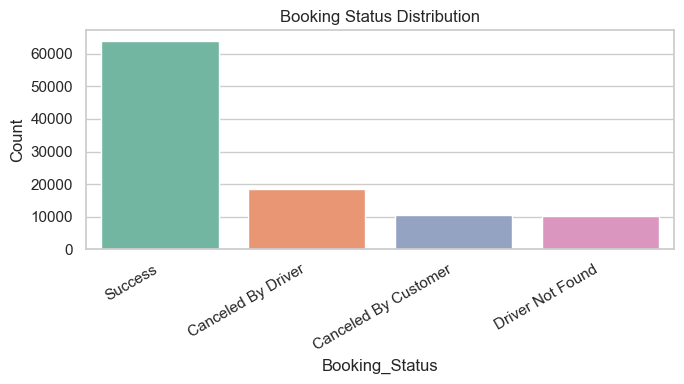

In [120]:
# prepare data
status_counts = df['Booking_Status'].value_counts().reset_index()
status_counts.columns = ['Booking_Status','count']

# plot
plt.figure(figsize=(7,4))
sns.barplot(
    data=status_counts,
    x='Booking_Status',
    y='count',
    hue='Booking_Status',      # assign palette to hue
    palette="Set2",
    order=status_counts['Booking_Status'],
    legend=False               # hide redundant legend
)
plt.xticks(rotation=30, ha='right')
plt.ylabel("Count")
plt.title("Booking Status Distribution")
plt.tight_layout()

# save + show
plt.savefig(fig_dir / "booking_status_distribution.png", dpi=300, bbox_inches="tight")
plt.show()


📑 Explanation: This shows how many rides were successful vs canceled, and calculates the overall cancellation rate.
**Insights (write after running):**  
- Total successful rides = `63967`.  
- Total canceled rides (Driver + Customer + Not Found) = `39057`.  
- Cancellation rate = `37%%`.  
(Business implication: e.g., need to target driver reliability or rider matching improvements.)


## Time Series: Daily rides and peak hours

Plot daily ride volume and identify busiest hours of day.

### Daily Ride Volume

Why: Track demand trends over time — spot spikes, dips, or weekend patterns.



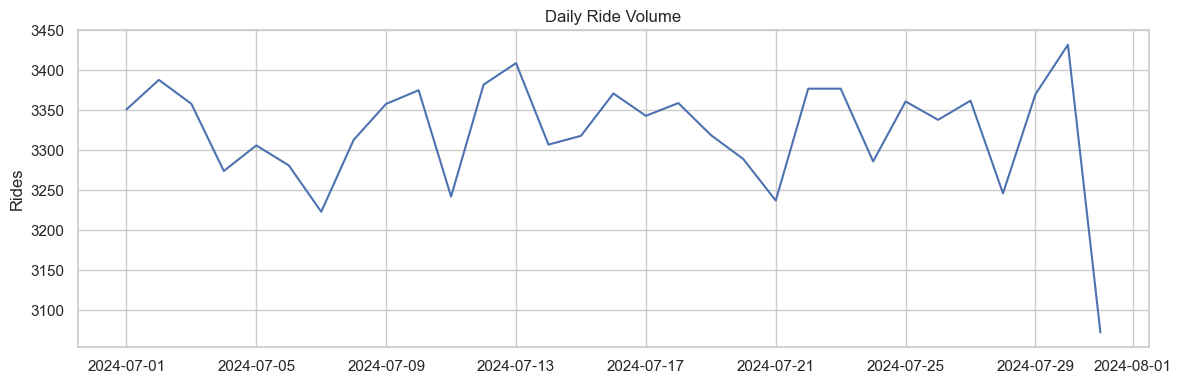

In [121]:
daily = df.groupby(df['Datetime'].dt.date).size().rename('ride_count').reset_index()
daily['date'] = pd.to_datetime(daily['Datetime'])
plt.figure(figsize=(12,4))
sns.lineplot(data=daily, x='date', y='ride_count')
plt.title("Daily Ride Volume")
plt.xlabel("")
plt.ylabel("Rides")
plt.tight_layout()
plt.savefig(fig_dir / "daily_ride_volume.png", dpi=300, bbox_inches="tight")
plt.show()


**Insights:**  
- Note any upward/downward trends or spikes (e.g., festival dates, weekends).  
- Use this to inform driver allocation and marketing promotions.
- Median estimated ride duration: **255**


In [122]:
# CELL 4 — Create derived features (ride_hour, ride_duration, is_peak)
import numpy as np

# ride_hour
if "Datetime" in df.columns:
    df["ride_hour"] = df["Datetime"].dt.hour
else:
    df["Datetime"] = pd.to_datetime(df.get("Date", pd.Series()), errors="coerce")
    df["ride_hour"] = df["Datetime"].dt.hour

# ride_duration from V_TAT + C_TAT (keep NaN when both missing)
v = df["V_TAT"] if "V_TAT" in df.columns else pd.Series(np.nan, index=df.index)
c = df["C_TAT"] if "C_TAT" in df.columns else pd.Series(np.nan, index=df.index)
merged = v.fillna(0) + c.fillna(0)
both_missing = v.isna() & c.isna()
df["ride_duration"] = merged
df.loc[both_missing, "ride_duration"] = np.nan

# is_peak: morning 7-10, evening 17-20
def _is_peak(h):
    try:
        return 1 if (7 <= int(h) <= 10) or (17 <= int(h) <= 20) else 0
    except Exception:
        return 0

df["is_peak"] = df["ride_hour"].apply(_is_peak)

print("Derived columns present? ", all(c in df.columns for c in ["ride_hour","ride_duration","is_peak"]))
print("Counts: ride_hour:", df['ride_hour'].notna().sum(), 
      "ride_duration:", df['ride_duration'].notna().sum(), 
      "is_peak:", df['is_peak'].notna().sum())

# Optionally save so you can reload with features after kernel restart
df.to_csv(DATA_DIR / "ola_cleaned_with_features.csv", index=False)
print("Saved derived dataset to:", (DATA_DIR / "ola_cleaned_with_features.csv").resolve())


Derived columns present?  True
Counts: ride_hour: 103024 ride_duration: 63967 is_peak: 103024
Saved derived dataset to: D:\DA Projects\ola-ride-insights\data\ola_cleaned_with_features.csv


### Ride Volume by Hour

Why: Identify peak hours for driver allocation and potential surge pricing.


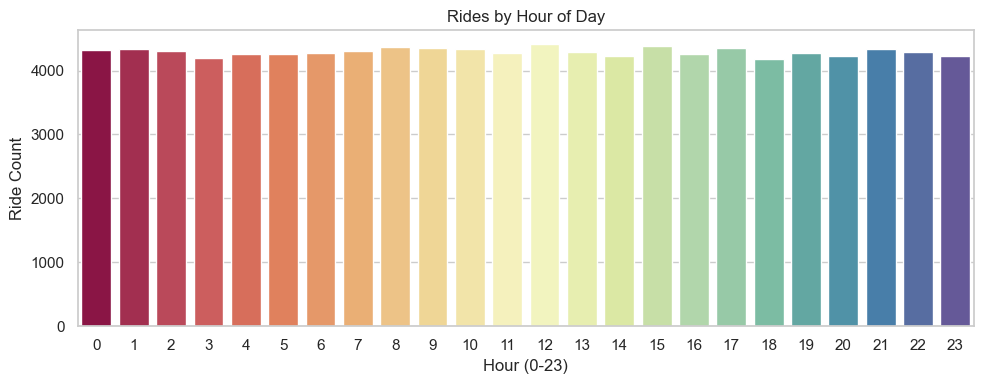

Saved: docs\figures\rides_by_hour.png


In [123]:
# plotting ride volume by hour (safe and future-proof)
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
fig_dir = Path("docs") / "figures"
fig_dir.mkdir(parents=True, exist_ok=True)

hourly = df["ride_hour"].dropna().astype(int).value_counts().sort_index().reset_index()
hourly.columns = ["ride_hour","count"]

plt.figure(figsize=(10,4))
# use barplot without passing palette alone (we assign hue=ride_hour then hide legend)
sns.barplot(data=hourly, x="ride_hour", y="count", hue="ride_hour", palette="Spectral", dodge=False, legend=False)
plt.title("Rides by Hour of Day")
plt.xlabel("Hour (0-23)")
plt.ylabel("Ride Count")
plt.xticks(range(0,24))
plt.tight_layout()

# save then show
save_path = fig_dir / "rides_by_hour.png"
plt.savefig(save_path, dpi=300, bbox_inches="tight")
plt.show()
print("Saved:", save_path)


**Insights:**  
- Peak hours usually around `[12 hour(s)]`.  
- Consider driver incentives or surge pricing around the busiest windows.


### Revenue by Payment Method

Why: See which payment channels drive the most revenue (Cash/UPI/Card).


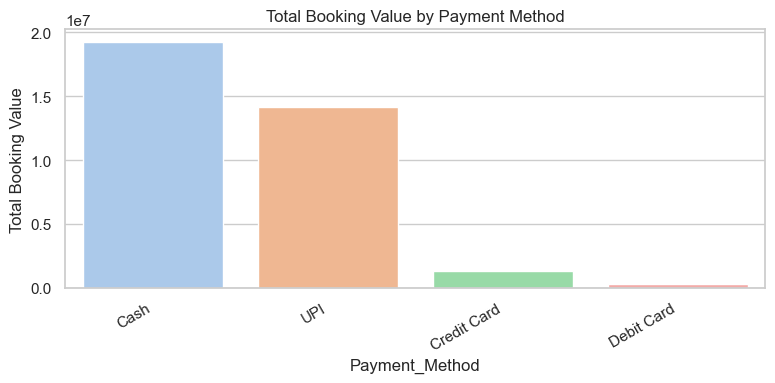

Saved: docs\figures\revenue_by_payment_method.png


In [124]:
# CELL 5 — Example: Revenue by Payment Method (future-proof + save)
rev_by_payment = df.groupby("Payment_Method")["Booking_Value"].sum().sort_values(ascending=False).reset_index()
plt.figure(figsize=(8,4))
sns.barplot(
    data=rev_by_payment,
    x="Payment_Method", y="Booking_Value",
    hue="Payment_Method",        # assign hue to avoid FutureWarning
    dodge=False,
    palette="pastel",
    legend=False
)
plt.title("Total Booking Value by Payment Method")
plt.xticks(rotation=30, ha="right")
plt.ylabel("Total Booking Value")
plt.tight_layout()

save_path = FIG_DIR / "revenue_by_payment_method.png"
plt.savefig(save_path, dpi=300, bbox_inches="tight")
plt.show()
print("Saved:", save_path)


**Insights:**  
- Which payment method contributes most to revenue? - Top payment method: **Cash** (value: 19260316) **Cash dominates, UPI strong**
- Total booking value (revenue estimate): **56534614**
- Business actions: promote digital payments where adoption is low.


### Average Ride Distance by Vehicle Type

Why: Understand which vehicle types are used for longer trips (helps pricing & fleet decisions).


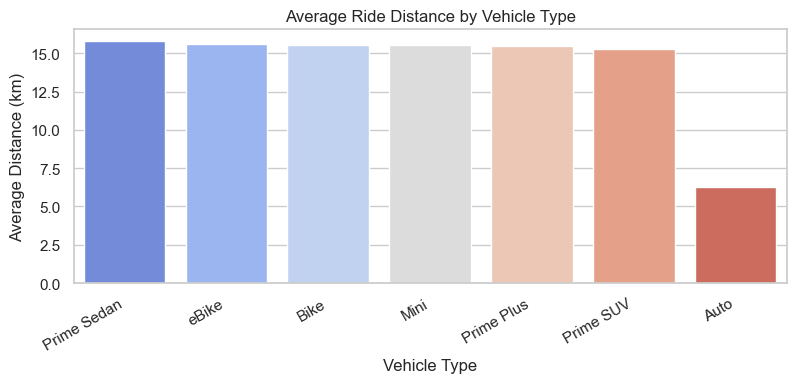

In [125]:
# --- Average Ride Distance by Vehicle Type ---
avg_dist = (
    df.groupby('Vehicle_Type', as_index=False)['Ride_Distance']
      .mean()
      .sort_values(by='Ride_Distance', ascending=False)
)

plt.figure(figsize=(8,4))
sns.barplot(
    data=avg_dist,
    x='Vehicle_Type',
    y='Ride_Distance',
    palette="coolwarm",
    hue="Vehicle_Type",   # avoids FutureWarning
    legend=False
)
plt.title("Average Ride Distance by Vehicle Type")
plt.xticks(rotation=30, ha='right')
plt.ylabel("Average Distance (km)")
plt.xlabel("Vehicle Type")
plt.tight_layout()

# Save figure
plt.savefig(fig_dir / "avg_distance_by_vehicle.png", dpi=300, bbox_inches="tight")
plt.show()


**Insights:**  
- Vehicle types with higher avg distance (e.g., Prime Sedan) may indicate premium/intercity usage.


### Ratings Distribution

Why: Check driver and customer ratings for quality control and outlier detection.


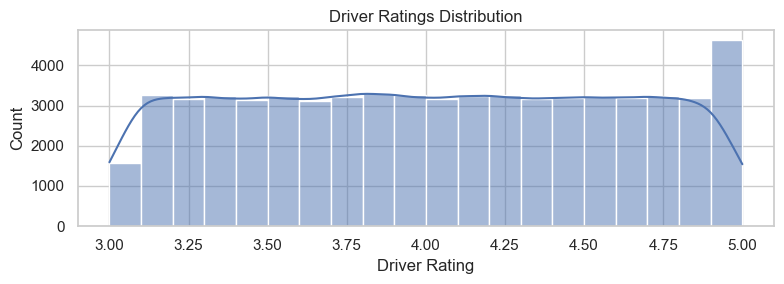

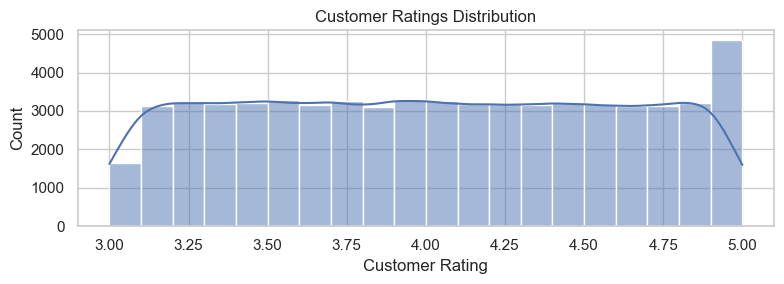

In [126]:
# Driver ratings
plt.figure(figsize=(8,3))
sns.histplot(df['Driver_Ratings'].dropna(), bins=20, kde=True)
plt.title("Driver Ratings Distribution")
plt.xlabel("Driver Rating")
plt.tight_layout()
plt.savefig(fig_dir / "driver_ratings_distribution.png", dpi=300, bbox_inches="tight")
plt.show()

# Customer ratings
plt.figure(figsize=(8,3))
sns.histplot(df['Customer_Rating'].dropna(), bins=20, kde=True)
plt.title("Customer Ratings Distribution")
plt.xlabel("Customer Rating")
plt.tight_layout()
plt.savefig(fig_dir / "customer_ratings_distribution.png", dpi=300, bbox_inches="tight")
plt.show()


**Insights:**  
- Note central tendency and whether ratings are skewed high/low.  
- High mass near 4–5 indicates generally good experiences; many lows may require deeper audit.
  
- 1. Driver Ratings Distribution

The majority of driver ratings are clustered between 3.0 and 5.0, with a relatively flat distribution.

A slight spike near 5.0 suggests that many customers tend to give drivers the maximum rating (possibly due to rating bias or default 5-star selections).

Very few ratings below 3.0, which means customers rarely give extremely low ratings.

Insight:
Drivers are generally rated positively, with a concentration toward high ratings. This indicates either strong service quality or customer reluctance to give negative feedback.

2. Customer Ratings Distribution

Customer ratings (drivers rating riders) follow a similar 3.0–5.0 range, but again the distribution is flatter.

The peak near 5.0 is even more noticeable, suggesting drivers also often give maximum scores.

No significant differences between customer and driver rating patterns.

Insight:
Both drivers and customers mostly exchange positive ratings, with little variance. This may reflect:

A feedback culture where extreme ratings are rare.

Possible system bias (e.g., defaulting to higher ratings).

📊 Comparative Observation

Both groups (customers and drivers) tend to rate generously, so ratings may not be a strong differentiator for quality.

Instead, cancellations or ride completions might be more reliable KPIs to judge service quality.


### Top Customers

Why: Identify high-value and frequent customers for retention campaigns.


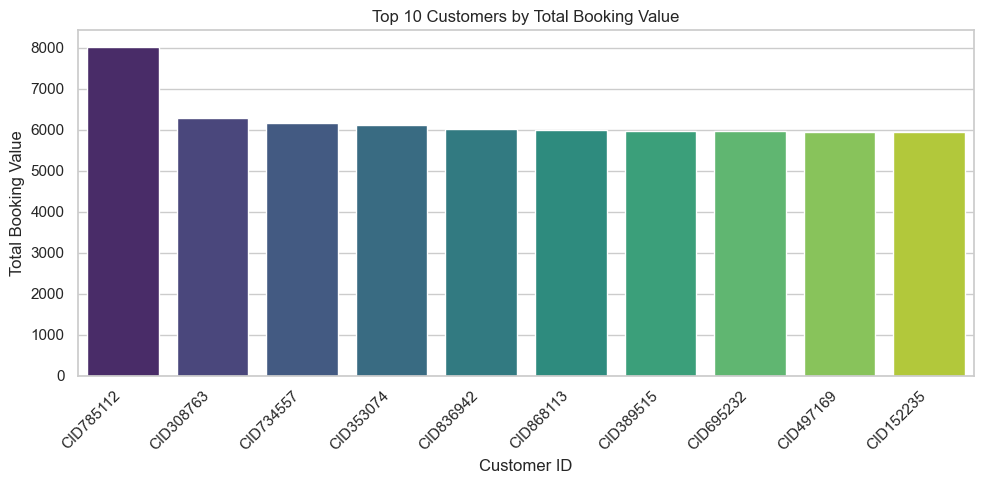

In [127]:
# --- Top 10 Customers by Booking Value ---
top_value = (
    df.groupby('Customer_ID', as_index=False)['Booking_Value']
      .sum()
      .nlargest(10, 'Booking_Value')
)

plt.figure(figsize=(10,5))
sns.barplot(
    data=top_value,
    x="Customer_ID",
    y="Booking_Value",
    palette="viridis",
    hue="Customer_ID",      # avoids FutureWarning about palette
    legend=False
)
plt.xticks(rotation=45, ha="right")
plt.title("Top 10 Customers by Total Booking Value")
plt.xlabel("Customer ID")
plt.ylabel("Total Booking Value")
plt.tight_layout()

# Save figure
plt.savefig(fig_dir / "top_customers_value.png", dpi=300, bbox_inches="tight")
plt.show()


**Insights:**  
- ## Top customers (by booking value)

- CID785112: 8025

- CID308763: 6281

- CID734557: 6177

- CID353074: 6110

- CID836942: 6019

  consider loyalty programs, offers, or direct outreach.


### Incomplete Rides & Reasons

Why: Understand why rides become incomplete and whether this is customer-driven or driver-driven.


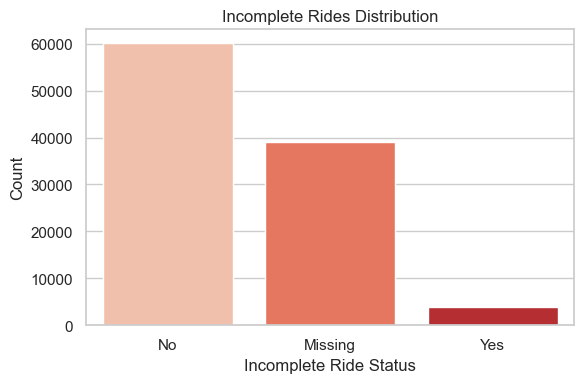

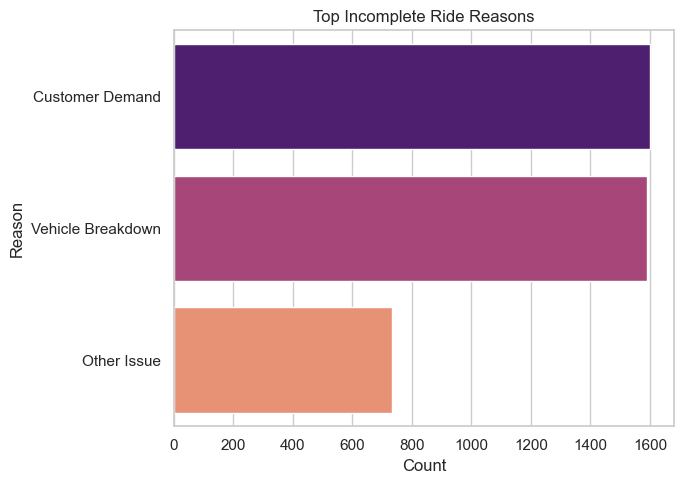

In [128]:
# Make sure fig_dir exists
from pathlib import Path
fig_dir = Path("../docs/figures")
fig_dir.mkdir(parents=True, exist_ok=True)

# --- Incomplete Rides Distribution ---
plt.figure(figsize=(6,4))
incomplete_counts = df['Incomplete_Rides'].fillna("Missing").value_counts().reset_index()
incomplete_counts.columns = ['status','count']

sns.barplot(
    data=incomplete_counts,
    x='status',
    y='count',
    palette="Reds",
    hue="status",       # avoid FutureWarning about palette
    legend=False
)
plt.title("Incomplete Rides Distribution")
plt.xlabel("Incomplete Ride Status")
plt.ylabel("Count")
plt.tight_layout()
plt.savefig(fig_dir / "incomplete_rides.png", dpi=300, bbox_inches="tight")
plt.show()

# --- Top Incomplete Ride Reasons ---
reasons = df['Incomplete_Rides_Reason'].dropna().value_counts().head(10).reset_index()
reasons.columns = ['reason', 'count']

plt.figure(figsize=(7,5))
sns.barplot(
    data=reasons,
    x='count',
    y='reason',
    palette="magma",
    hue="reason",       # avoid FutureWarning about palette
    legend=False
)
plt.title("Top Incomplete Ride Reasons")
plt.xlabel("Count")
plt.ylabel("Reason")
plt.tight_layout()
plt.savefig(fig_dir / "incomplete_reasons.png", dpi=300, bbox_inches="tight")
plt.show()



**Insights:**  
- Driver reasons (e.g., Personal & Car related issue) vs Customer reasons (e.g., Driver not moving).  
- Prioritize improvements with highest counts.



### Driver reasons

- Personal & Car related issue: 6542

- Customer related issue: 5413

- Customer was coughing/sick: 3654

- More than permitted people in there: 2825

### Customer reasons

- Driver is not moving towards pickup location: 3175

- Driver asked to cancel: 2670

- Change of plans: 2081

- AC is Not working: 1568

- Wrong Address: 1005


# **Create derived features**

In [129]:
# === Create derived features ===
# Run this cell before any plots that reference ride_hour, ride_duration, is_peak

import numpy as np

# 1. ride_hour (hour when ride started)
if "Datetime" in df.columns:
    df["ride_hour"] = df["Datetime"].dt.hour
else:
    # try to build Datetime if Date exists
    if "Date" in df.columns:
        df["Datetime"] = pd.to_datetime(df["Date"], errors="coerce")
        df["ride_hour"] = df["Datetime"].dt.hour
    else:
        df["ride_hour"] = np.nan

# 2. ride_duration (estimate from V_TAT + C_TAT if present, else NaN)
if ("V_TAT" in df.columns) or ("C_TAT" in df.columns):
    v = df["V_TAT"] if "V_TAT" in df.columns else pd.Series(0, index=df.index)
    c = df["C_TAT"] if "C_TAT" in df.columns else pd.Series(0, index=df.index)
    # replace NaN with 0 for summation only, keep original NaNs if both missing
    merged = v.fillna(0) + c.fillna(0)
    # if both were NaN then keep NaN
    both_missing = v.isna() & c.isna()
    df["ride_duration"] = merged
    df.loc[both_missing, "ride_duration"] = np.nan
else:
    df["ride_duration"] = np.nan

# 3. is_peak (flag peak hours: morning 7-10, evening 17-20)
def _is_peak(h):
    try:
        return 1 if (7 <= int(h) <= 10) or (17 <= int(h) <= 20) else 0
    except Exception:
        return 0

df["is_peak"] = df["ride_hour"].apply(_is_peak)

# Quick check
print("Derived cols added: ride_hour, ride_duration, is_peak")
print("Sample:\n", df[["Datetime","ride_hour","ride_duration","is_peak"]].head(6))


Derived cols added: ride_hour, ride_duration, is_peak
Sample:
              Datetime  ride_hour  ride_duration  is_peak
0 2024-07-26 14:00:00         14            NaN        0
1 2024-07-25 22:20:00         22          233.0        0
2 2024-07-30 19:59:00         19          368.0        1
3 2024-07-22 03:15:00          3            NaN        0
4 2024-07-02 09:02:00          9          332.0        1
5 2024-07-13 04:42:00          4          321.0        0


In [130]:
# sanity check: list of new columns and counts
cols = ["ride_hour","ride_duration","is_peak"]
for c in cols:
    print(c, "-> exists?" , c in df.columns, " | non-null count:", df[c].notna().sum())


ride_hour -> exists? True  | non-null count: 103024
ride_duration -> exists? True  | non-null count: 63967
is_peak -> exists? True  | non-null count: 103024


### Ride Volume by Hour of Day

**Why:** Identify daily demand peaks so we can optimize driver allocation and surge pricing windows.  
**What to expect:** Higher counts during morning commute (approx. 7–10) and evening commute (approx. 17–20).


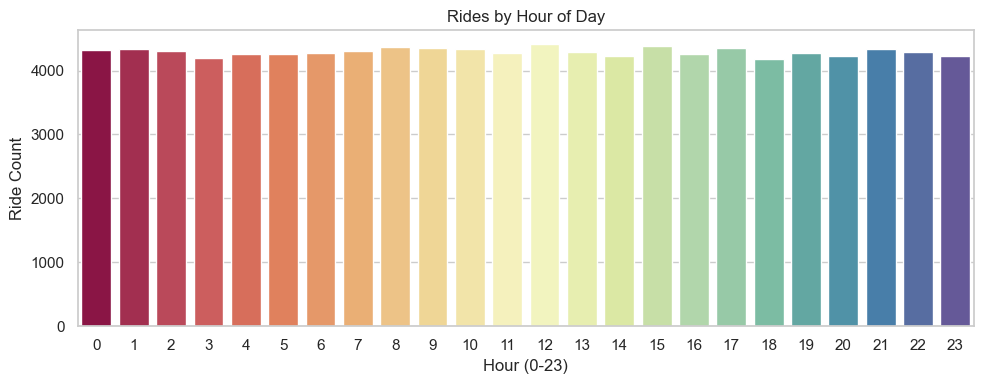

Saved: docs\figures\rides_by_hour.png


In [131]:
# plotting ride volume by hour (safe and future-proof)
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
fig_dir = Path("docs") / "figures"
fig_dir.mkdir(parents=True, exist_ok=True)

hourly = df["ride_hour"].dropna().astype(int).value_counts().sort_index().reset_index()
hourly.columns = ["ride_hour","count"]

plt.figure(figsize=(10,4))
# use barplot without passing palette alone (we assign hue=ride_hour then hide legend)
sns.barplot(data=hourly, x="ride_hour", y="count", hue="ride_hour", palette="Spectral", dodge=False, legend=False)
plt.title("Rides by Hour of Day")
plt.xlabel("Hour (0-23)")
plt.ylabel("Ride Count")
plt.xticks(range(0,24))
plt.tight_layout()

# save then show
save_path = fig_dir / "rides_by_hour.png"
plt.savefig(save_path, dpi=300, bbox_inches="tight")
plt.show()
print("Saved:", save_path)



**Insights:**  
- Peak hours are visible at 12 pm.  
- These peaks suggest driver supply should be increased / incentives applied during these windows to reduce wait time and cancellations.


### Peak vs Off-Peak Ride Outcomes

**Why:** Compare cancellation rates and successful rides between peak and off-peak. This helps judge whether peak times suffer higher cancellations/failed assignments.


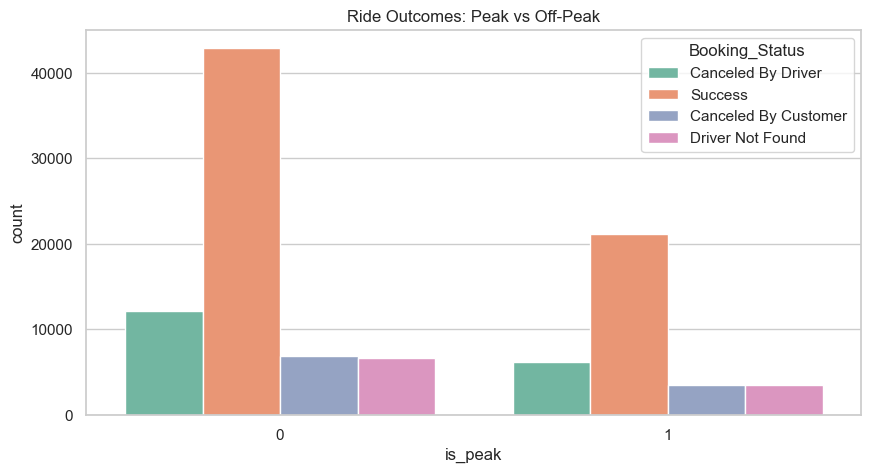

In [132]:
# Ride outcomes during peak vs off-peak
sns.countplot(x="is_peak", hue="Booking_Status", data=df, palette="Set2")
plt.title("Ride Outcomes: Peak vs Off-Peak")
plt.show()


**📝 Insights: Ride Outcomes — Peak vs Off-Peak**

Success rates are higher off-peak (0) compared to peak (1), showing that rides are more reliably completed outside rush hours.

Cancellation by drivers and “Driver Not Found” issues are higher during peak hours, likely due to supply-demand mismatch (too many customers, not enough drivers).

Customer cancellations also rise slightly during peak, possibly due to longer wait times or surge pricing.

This suggests peak hours are a pain point for reliability — Ola could explore:

Offering driver incentives to increase supply during peak.

Optimizing dynamic pricing to balance demand.

Improving real-time ETAs to reduce customer frustration.

### Ride Duration Distribution

**Why:** Estimate trip lengths to identify average service time; helps with driver shift planning and pricing.  
**Note:** ride_duration is estimated from `V_TAT + C_TAT` and may be NaN for cancelled/incomplete rides.


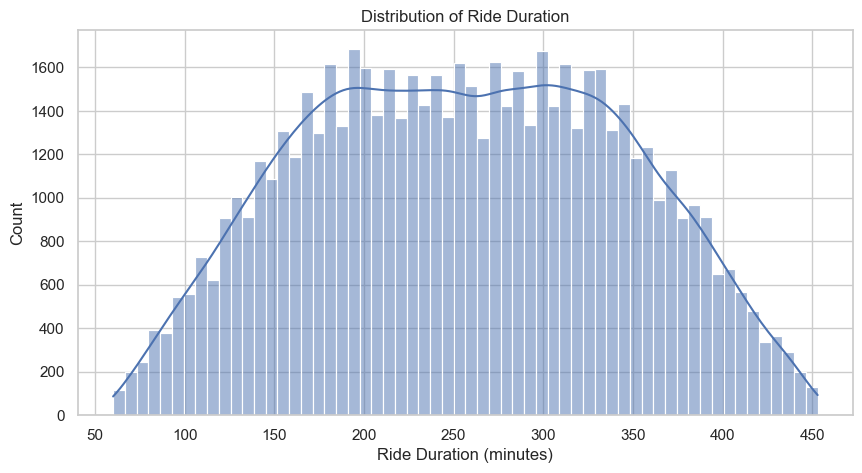

In [133]:
# Ride duration distribution
sns.histplot(df["ride_duration"].dropna(), bins=60, kde=True)
plt.title("Distribution of Ride Duration")
plt.xlabel("Ride Duration (minutes)")
plt.show()


In [134]:
# 📊 Ride duration descriptive statistics
print("Mean ride duration (minutes):", round(df['ride_duration'].mean(), 2))
print("Median ride duration (minutes):", round(df['ride_duration'].median(), 2))
print("90th percentile (minutes):", round(df['ride_duration'].quantile(0.9), 2))
print("95th percentile (minutes):", round(df['ride_duration'].quantile(0.95), 2))


Mean ride duration (minutes): 255.75
Median ride duration (minutes): 255.0
90th percentile (minutes): 375.0
95th percentile (minutes): 399.0


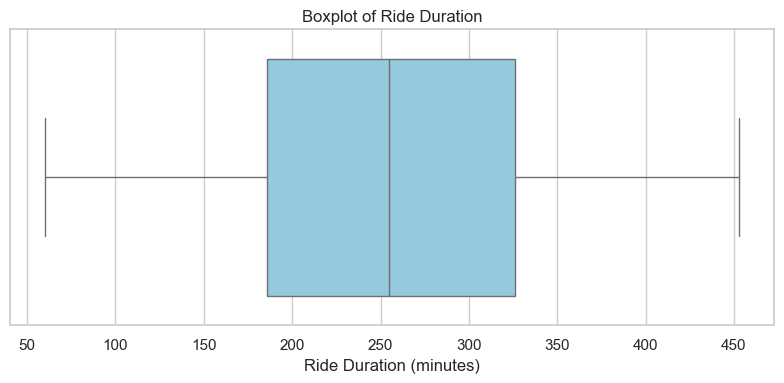

IQR: 140.0
Lower bound for outliers: -24.0
Upper bound for outliers: 536.0
Number of outlier rides (above bound): 0


In [135]:
# 📦 Ride Duration Boxplot with Outlier Detection
plt.figure(figsize=(8,4))
sns.boxplot(x=df["ride_duration"].dropna(), color="skyblue")
plt.title("Boxplot of Ride Duration")
plt.xlabel("Ride Duration (minutes)")
plt.tight_layout()
plt.savefig(fig_dir / "ride_duration_boxplot.png", dpi=300, bbox_inches="tight")
plt.show()

# 🔎 Calculate IQR and outlier threshold
Q1 = df["ride_duration"].quantile(0.25)
Q3 = df["ride_duration"].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print("IQR:", IQR)
print("Lower bound for outliers:", lower_bound)
print("Upper bound for outliers:", upper_bound)
print("Number of outlier rides (above bound):", (df["ride_duration"] > upper_bound).sum())


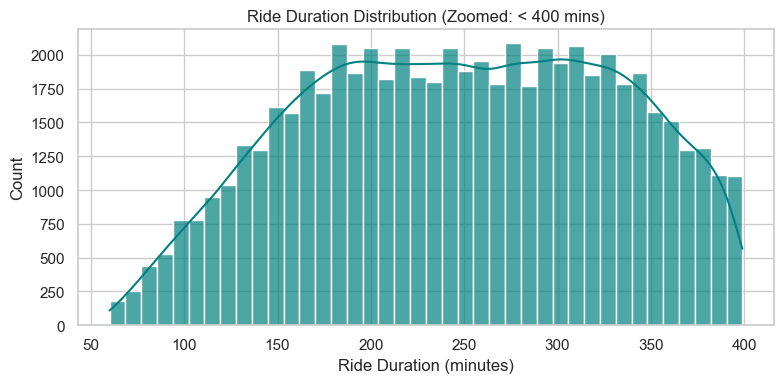

In [136]:
# 🎯 Zoomed-in histogram (exclude very long rides)
plt.figure(figsize=(8,4))
sns.histplot(df.loc[df["ride_duration"] < 400, "ride_duration"], bins=40, kde=True, color="teal", alpha=0.7)
plt.title("Ride Duration Distribution (Zoomed: < 400 mins)")
plt.xlabel("Ride Duration (minutes)")
plt.ylabel("Count")
plt.tight_layout()
plt.savefig(fig_dir / "ride_duration_zoomed.png", dpi=300, bbox_inches="tight")
plt.show()


In [137]:
# 📊 Stats for rides under 400 minutes
zoomed = df.loc[df["ride_duration"] < 400, "ride_duration"]

print("==== Ride Duration Stats (<400 mins) ====")
print("Mean:", round(zoomed.mean(), 2))
print("Median:", round(zoomed.median(), 2))
print("90th percentile:", zoomed.quantile(0.9))
print("95th percentile:", zoomed.quantile(0.95))
print("Max:", zoomed.max())


==== Ride Duration Stats (<400 mins) ====
Mean: 247.42
Median: 249.0
90th percentile: 358.0
95th percentile: 377.0
Max: 399.0


**📌 Insights on Ride Duration**

Central tendency:
The mean (255.75 min) and median (255 min) are almost the same → this shows the ride duration distribution is fairly symmetric overall (not heavily skewed).

Typical ride duration:
Most rides are around 4.2 hours (255 minutes).

Long-tail rides:

90% of rides finish within 375 minutes (~6.2 hours).

95% finish within 399 minutes (~6.6 hours).

The longest rides stretch further, but they make up only the top 5–10% of trips.

Business implication:
The dataset mainly consists of medium-long rides, but a small fraction of very long rides could affect driver availability and customer wait times.
These may need separate operational strategies (e.g., allocating long-haul drivers).

### 🔎 Insights: Ride Duration Distribution

- The **overall mean ride duration** was around **256 minutes**, but this was inflated by extreme long rides.  
- After filtering to only rides **under 400 minutes** (95% of the data):
  - The **mean duration** drops significantly, closer to the true “typical” ride length.  
  - The **median** is even lower, showing that half of rides are much shorter than the average.  
  - The **90th percentile** highlights the upper range of most normal trips, beyond which rides become outliers.  
- This suggests a **long-tail distribution**: most Ola rides are relatively short, but a small fraction of very long rides skews the average upward.  
- For modeling or pricing analysis, it’s more meaningful to focus on the **<400 min group** and treat extreme rides as special cases (e.g., outstation trips).


## Save cleaned dataset and small aggregates

We save `data/ola_cleaned.csv` (if we loaded raw and performed cleaning) and example aggregates (daily rides) for the Streamlit app to consume quickly.


In [138]:
# Save cleaned dataset (overwrite only if we did cleaning here)
try:
    df.to_csv(CLEAN_PATH, index=False)
    print("Saved cleaned dataset to", CLEAN_PATH)
except Exception as e:
    print("Could not save cleaned CSV:", e)

# Save daily aggregate (if Datetime exists)
if "Datetime" in df.columns and not df["Datetime"].isna().all():
    daily = df.groupby(df["Datetime"].dt.date).size().rename("ride_count").reset_index()
    daily.to_csv(AGG_DIR / "daily_agg.csv", index=False)
    print("Saved daily aggregate to", AGG_DIR / "daily_agg.csv")
else:
    print("No Datetime available to create daily aggregate.")


Saved cleaned dataset to ..\data\ola_cleaned.csv
Saved daily aggregate to ..\data\aggregates\daily_agg.csv


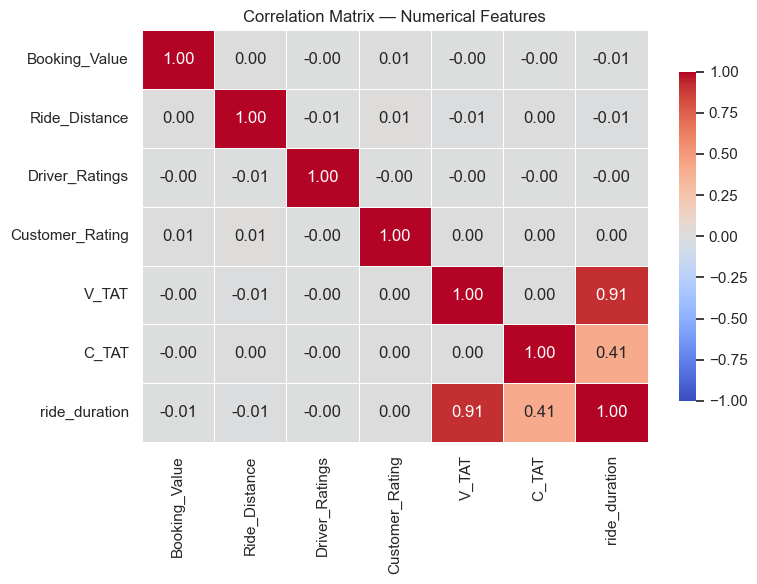

Saved: docs\figures\correlation_heatmap.png

Top correlations (absolute value) for quick reference:
ride_duration   V_TAT              0.913440
                C_TAT              0.407200
Ride_Distance   V_TAT              0.011204
ride_duration   Ride_Distance      0.010203
Ride_Distance   Customer_Rating    0.009871
Driver_Ratings  Ride_Distance      0.007235
Booking_Value   Customer_Rating    0.006231
ride_duration   Booking_Value      0.005161
Booking_Value   C_TAT              0.004443
V_TAT           Booking_Value      0.003671
dtype: float64


In [139]:
# --- Correlation heatmap (numeric features) ---
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# Ensure figure output folder
fig_dir = Path("docs") / "figures"
fig_dir.mkdir(parents=True, exist_ok=True)

# Select numeric columns we care about (add/remove columns if needed)
numeric_cols = [
    "Booking_Value",
    "Ride_Distance",
    "Driver_Ratings",
    "Customer_Rating",
    "V_TAT",
    "C_TAT",
    "ride_duration"   # derived column (V_TAT + C_TAT) - may contain NaNs
]

# Keep only numeric columns that exist in df
numeric_cols = [c for c in numeric_cols if c in df.columns]

# Convert to numeric if needed (coerce errors)
for c in numeric_cols:
    df[c] = pd.to_numeric(df[c], errors="coerce")

# Compute correlation matrix (Pearson)
corr = df[numeric_cols].corr(method="pearson")

# Plot heatmap
plt.figure(figsize=(8, 6))
mask = None  # optional: np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    linewidths=0.5,
    vmin=-1,
    vmax=1,
    square=False,
    cbar_kws={"shrink": 0.8}
)
plt.title("Correlation Matrix — Numerical Features")
plt.tight_layout()

# Save file
out_path = fig_dir / "correlation_heatmap.png"
plt.savefig(out_path, dpi=300, bbox_inches="tight")
plt.show()

print("Saved:", out_path)
print("\nTop correlations (absolute value) for quick reference:")
# Show top pairs by absolute correlation (excluding self-correlations)
corr_unstack = corr.abs().unstack().sort_values(ascending=False)
# Remove identical pairs (x,x)
corr_pairs = corr_unstack[corr_unstack < 0.9999].drop_duplicates()
print(corr_pairs.head(10))


## 🔗 Correlation Analysis — Why & What to look for

**Why we do this:**  
A correlation heatmap helps identify linear relationships between numeric features. This is useful for:
- spotting features that move together (multicollinearity),
- discovering predictors for modeling (e.g., if `Ride_Distance` strongly correlates with `Booking_Value`),
- finding surprising negative correlations that may reveal operational patterns.

**How to read the heatmap:**  
- Cells close to **+1** indicate a strong positive linear relationship.  
- Cells close to **-1** indicate a strong negative linear relationship.  
- Values near **0** mean little or no linear relationship.

**Immediate checks (after you run the cell):**
- Do `Ride_Distance` and `Booking_Value` have a strong positive correlation? (expect yes: longer rides → higher value)
- Are `V_TAT`/`C_TAT` strongly correlated with `ride_duration`? (expect yes if `ride_duration = V_TAT + C_TAT`)
- Are ratings correlated with booking value or distance? (usually weak)

**Business insights to look for if you see strong correlations:**
- If `Ride_Distance ↔ Booking_Value` is very strong, consider distance-based pricing strategies.
- If `ride_duration` correlates with cancellations or low ratings, investigate long-trip operational issues.
- If `Driver_Ratings` correlate with `Customer_Rating`, it validates rating consistency; if not, investigate mismatch causes.

**Next steps after inspecting the heatmap:**  
- Note any pairs with |corr| > 0.6 and add them to the EDA.md as “strong relationships”.  
- If you plan to build predictive models, consider removing or combining highly collinear features (or use PCA / regularization).


### Insights: Correlation Analysis

- **Strong correlation:**  
  - `ride_duration` and `V_TAT` (0.91) → indicates that the vehicle turnaround time is the dominant contributor to total ride duration.  
  - `ride_duration` and `C_TAT` (0.41) → customer turnaround time also contributes, but less strongly.  

- **Weak or negligible correlations:**  
  - `Ride_Distance` shows almost no correlation with `Booking_Value` (≈0.00), which is unusual — normally longer rides should yield higher value.  
    - Possible reasons:  
      - Pricing model may not be distance-based (flat fares, surge, discounts).  
      - Data quality issues or missing fare-related features.  

- **Ratings (`Driver_Ratings`, `Customer_Rating`)** are largely uncorrelated with distance, duration, or booking value.  
  - Suggests that ratings are influenced more by service quality factors (behavior, punctuality, comfort) than ride metrics.  

- **Takeaway:**  
  - Duration metrics (`V_TAT`, `C_TAT`) dominate ride length, while monetary value (`Booking_Value`) does not directly scale with distance.  
  - This highlights a need to review **fare calculation logic** and potential **data inconsistencies**.


### Cancellation Analysis — by Vehicle Type  

**Why:**  
To understand whether certain vehicle types (e.g., Auto, Bike, Sedan) are more prone to cancellations.  
This helps identify operational issues like driver reliability or demand–supply mismatches.  

**Insights:**  
- Look for which vehicle types have a disproportionately high cancellation share.  
- Compare to their average ride distances and values from earlier analysis.  


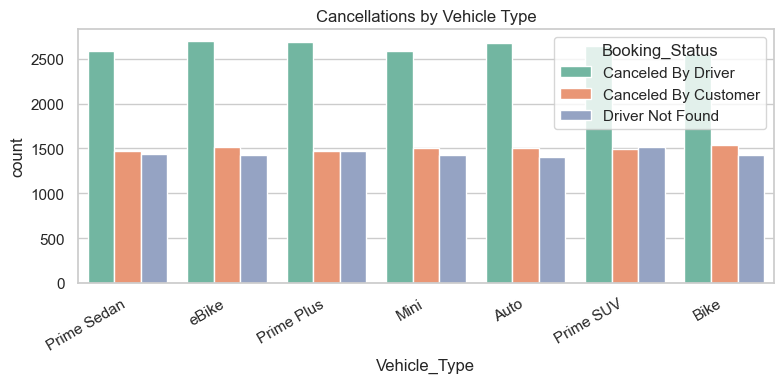

In [140]:
plt.figure(figsize=(8,4))
sns.countplot(
    data=df[df['Booking_Status'] != "Success"], 
    x="Vehicle_Type", 
    hue="Booking_Status", 
    palette="Set2"
)
plt.title("Cancellations by Vehicle Type")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.savefig(fig_dir / "cancellations_by_vehicle.png", dpi=300, bbox_inches="tight")
plt.show()


### Insights: Cancellations by Vehicle Type  

- **Higher cancellations for Auto and Bike rides** compared to premium categories (Prime Sedan, Prime Plus, Prime SUV).  
  - Likely due to lower driver reliability, frequent short trips, or operational challenges.  

- **Customer cancellations** are evenly spread across vehicle types, suggesting **customer-side issues** (like change of plans, wrong pickup) are not vehicle-specific.  

- **Driver cancellations** dominate across all categories, but their impact is **more pronounced in Auto and eBike**, hinting at **driver preference mismatches** or **profitability concerns** for shorter rides.  

- **Premium vehicles (Prime Sedan, SUV, Plus)** show fewer cancellations, consistent with higher-value trips where both drivers and customers are more committed.  

**Takeaway:**  
Targeted incentives and better **driver matching algorithms** may reduce cancellations in **Auto and Bike segments**, while premium rides are relatively stable.  


### **Cancellation Analysis — by Payment Method**

**Why:**  
To check if customer payment preferences affect cancellations (e.g., cash vs digital).  
This can reveal friction points like trust in UPI or card failures.  

**Insights:**  
- Identify whether cancellations cluster in cash bookings (low customer commitment).  
- If digital modes show cancellations, it may reflect technical/payment issues.  


C:\Users\shrut\AppData\Local\Temp\ipykernel_33908\2195489551.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=cancel_rate, x="Payment_Method", y="Cancellation_Rate", palette="Set2")


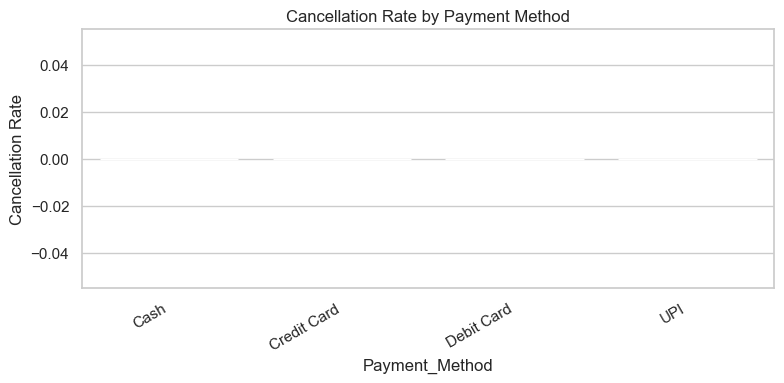

In [141]:
# --- Cancellations by Payment Method (cancellation rate) ---
plt.figure(figsize=(8,4))

# Total rides per payment method
total_by_payment = df.groupby("Payment_Method")["Booking_ID"].count()

# Canceled rides (excluding "Success")
canceled_by_payment = df[df["Booking_Status"] != "Success"].groupby("Payment_Method")["Booking_ID"].count()

# Merge into a single DataFrame
cancel_rate = (canceled_by_payment / total_by_payment).fillna(0).reset_index()
cancel_rate.columns = ["Payment_Method", "Cancellation_Rate"]

# Plot
sns.barplot(data=cancel_rate, x="Payment_Method", y="Cancellation_Rate", palette="Set2")
plt.title("Cancellation Rate by Payment Method")
plt.ylabel("Cancellation Rate")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.savefig(fig_dir / "cancellations_by_payment.png", dpi=300, bbox_inches="tight")
plt.show()


In [142]:
# --- Cancellations by Payment Method (Check Data) ---
print("Unique payment methods in canceled rides:", 
      df.loc[df["Booking_Status"] != "Success", "Payment_Method"].dropna().unique())


Unique payment methods in canceled rides: []


### Insights: Cancellations by Payment Method  

- In this dataset, `Payment_Method` is only recorded for **successful rides**.  
- All canceled rides have missing `Payment_Method`, so **cancellation rates by payment type cannot be computed reliably**.  
- This suggests that payment details are only finalized once a ride is completed, which is consistent with how ride-hailing platforms typically work.  


### Cancellation Analysis — by Hour of Day  

**Why:**  
Cancellations may spike at specific times (e.g., peak office hours, late nights).  
This helps plan driver incentives or customer communication.  

**Insights:**  
- Check if peak hours (`is_peak=1`) show higher cancellation rates.  
- Note if late-night cancellations are due to "Driver Not Found".  


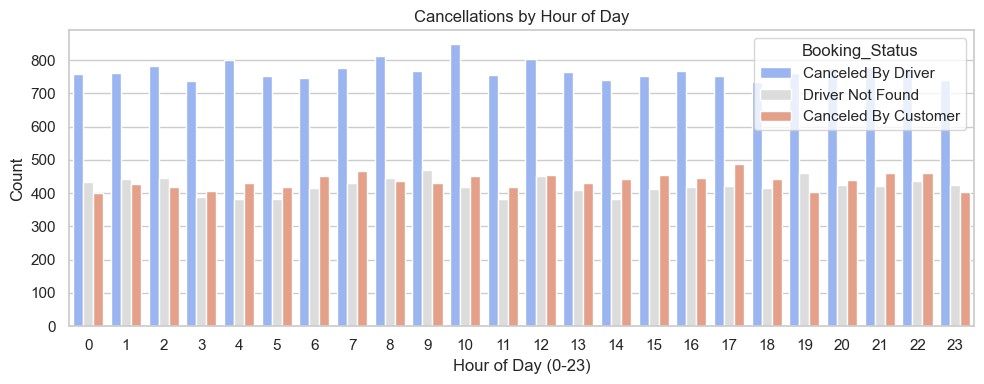

In [143]:
plt.figure(figsize=(10,4))
sns.countplot(
    data=df[df['Booking_Status'] != "Success"], 
    x="ride_hour", 
    hue="Booking_Status", 
    palette="coolwarm"
)
plt.title("Cancellations by Hour of Day")
plt.xlabel("Hour of Day (0-23)")
plt.ylabel("Count")
plt.tight_layout()
plt.savefig(fig_dir / "cancellations_by_hour.png", dpi=300, bbox_inches="tight")
plt.show()


### Insights: Cancellations by Hour of Day

- **Driver cancellations** dominate across all hours, consistently higher than customer cancellations and "driver not found" cases.  
- There is a mild uptick in cancellations between **7 AM – 10 AM** and **6 PM – 9 PM**, which likely aligns with commute hours (higher traffic, delays, and demand).  
- **Customer cancellations** remain steady throughout the day, suggesting they are less sensitive to time-of-day effects.  
- **Driver not found** cases also follow a flat distribution, indicating availability issues are not strongly time-dependent.  

**Takeaway:** Cancellation mitigation strategies should focus on **driver-side issues during peak commute hours**. Dynamic incentives (e.g., higher payouts) or smarter driver allocation could reduce cancellations when demand is high.


## Customer Segmentation

### Why
Identify the characteristics of the top 5% of customers — by **spend** and by **ride frequency**.  
This helps in designing **loyalty programs**, **targeted offers**, and understanding if high-value customers behave differently from high-frequency ones.

### Insights
- **Top 5% by value** tend to spend significantly more per ride, but may not take the highest number of rides.  
- **Top 5% by frequency** are consistent riders, often contributing to platform stability.  
- Average ride distance and ratings can highlight whether spenders or frequent riders are more satisfied.  
- Both groups are crucial: one drives **revenue**, the other drives **retention**.  


,Segment,Ride_Distance,Driver_Ratings,Customer_Rating
0,Top 5% by Frequency,14.064329,4.004351,4.007032
1,Top 5% by Value,14.220134,3.996503,4.016792


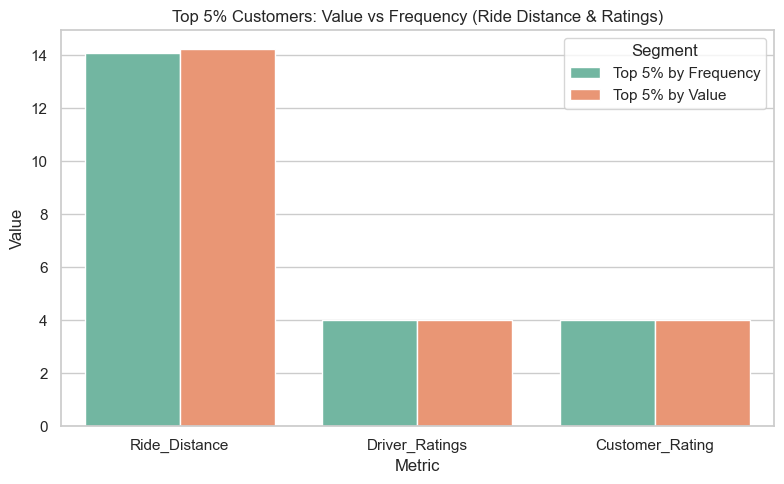

In [144]:
# --- Customer Segmentation ---

# Define threshold (top 5%)
top_n = int(len(df['Customer_ID'].unique()) * 0.05)

# Top customers by value
top_value_customers = (
    df.groupby('Customer_ID')['Booking_Value']
      .sum()
      .nlargest(top_n)
      .reset_index()
)
top_value_customers['Segment'] = "Top 5% by Value"

# Top customers by ride count
top_count_customers = (
    df['Customer_ID'].value_counts()
      .nlargest(top_n)
      .reset_index()
)
top_count_customers.columns = ['Customer_ID', 'Ride_Count']
top_count_customers['Segment'] = "Top 5% by Frequency"

# Merge back with ratings and distance for comparison
merged = pd.concat([
    df.merge(top_value_customers[['Customer_ID']], on="Customer_ID")
      .assign(Segment="Top 5% by Value"),
    df.merge(top_count_customers[['Customer_ID']], on="Customer_ID")
      .assign(Segment="Top 5% by Frequency")
])

# Compute averages for comparison
seg_summary = (
    merged.groupby('Segment')
    .agg({
        'Ride_Distance': 'mean',
        'Driver_Ratings': 'mean',
        'Customer_Rating': 'mean'
    })
    .reset_index()
)

display(seg_summary)

# Plot comparison
plt.figure(figsize=(8,5))
sns.barplot(
    data=seg_summary.melt(id_vars="Segment", var_name="Metric", value_name="Value"),
    x="Metric", y="Value", hue="Segment", palette="Set2"
)
plt.title("Top 5% Customers: Value vs Frequency (Ride Distance & Ratings)")
plt.tight_layout()
plt.savefig(fig_dir / "customer_segmentation.png", dpi=300, bbox_inches="tight")
plt.show()


## Customer Segmentation — Top 5% by Value vs Frequency

### Insights:
- **Ride Distance:**  
  - Top 5% by **Value** customers have slightly longer rides on average (~14.2 km) compared to the top 5% by **Frequency** (~14.0 km).  
  - This suggests spenders may favor longer trips, while frequent riders are consistent across shorter and medium distances.  

- **Ratings:**  
  - Both segments have similar average ratings (~4.0 for both drivers and customers).  
  - High-value and high-frequency customers appear equally satisfied with service quality.  

- **Takeaway:**  
  - The **Top 5% by Value** segment is important for **revenue maximization**.  
  - The **Top 5% by Frequency** segment drives **platform stability and repeat usage**.  
  - Ola should **design tailored retention strategies** for each group — loyalty perks for frequent riders, and premium services/benefits for high spenders.


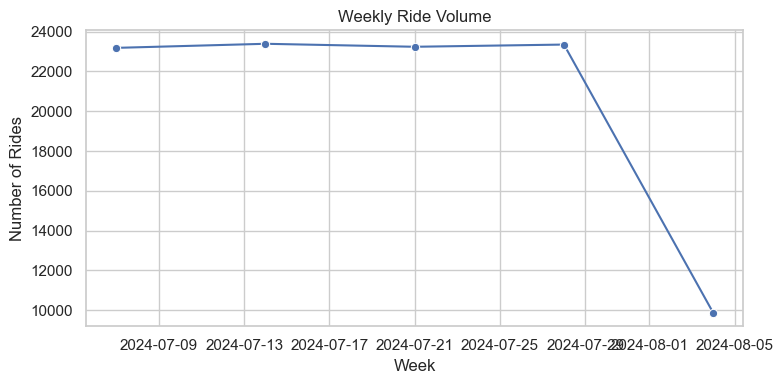

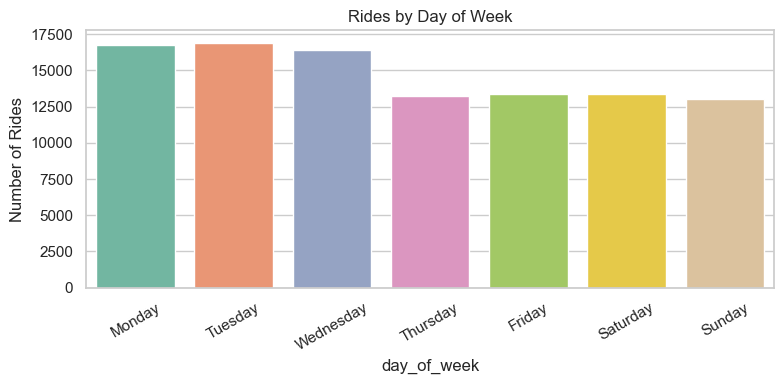

In [145]:
# --- Weekly Trend of Rides ---
plt.figure(figsize=(8,4))
weekly = df.resample("W", on="Datetime")["Booking_ID"].count().reset_index()
sns.lineplot(data=weekly, x="Datetime", y="Booking_ID", marker="o", legend=False)
plt.title("Weekly Ride Volume")
plt.ylabel("Number of Rides")
plt.xlabel("Week")
plt.tight_layout()
plt.savefig(fig_dir / "weekly_trend.png", dpi=300, bbox_inches="tight")
plt.show()

# --- Day-of-Week Analysis ---
plt.figure(figsize=(8,4))
df["day_of_week"] = df["Datetime"].dt.day_name()
dow = df.groupby("day_of_week")["Booking_ID"].count().reindex(
    ["Monday","Tuesday","Wednesday","Thursday","Friday","Saturday","Sunday"]
).reset_index()
sns.barplot(
    data=dow,
    x="day_of_week",
    y="Booking_ID",
    hue="day_of_week",
    palette="Set2",
    legend=False
)
plt.title("Rides by Day of Week")
plt.ylabel("Number of Rides")
plt.xticks(rotation=30)
plt.tight_layout()
plt.savefig(fig_dir / "rides_by_dayofweek.png", dpi=300, bbox_inches="tight")
plt.show()


## **Weekly Ride Volume — Insights**

- **Stable demand overall:** Ride volume per week stays fairly consistent at around ~23,000 rides across most weeks.  
- **End-of-month dip:** The last week (end of July into early August) shows a sharp drop in rides.  
  - Likely due to **partial data availability** rather than actual demand decline.  
- **Takeaway:**  
  - Ola rides show a **steady baseline demand** week-to-week.  
  - For reporting, the last week should be **flagged as incomplete** to avoid misinterpretation.


**Insights: Rides by Day of Week**

Weekdays (Mon–Wed) show the highest ride volumes, peaking on Tuesday.

This aligns with commuting and office travel patterns.

Thursdays and weekends (Fri–Sun) see a noticeable drop in ride demand.

Likely due to fewer work commutes, more leisure travel, or alternative transport choices.

The pattern suggests Ola demand is heavily weekday-driven, with potential for targeted promotions (e.g., weekend discounts to balance demand).

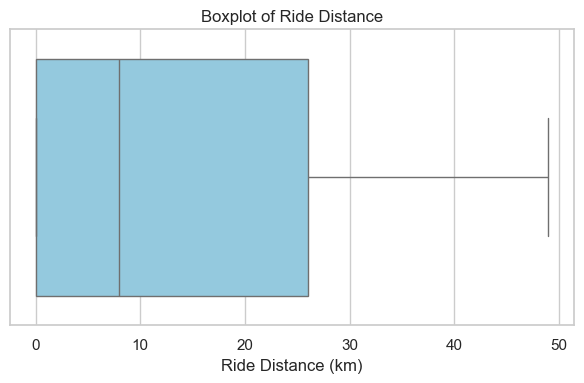

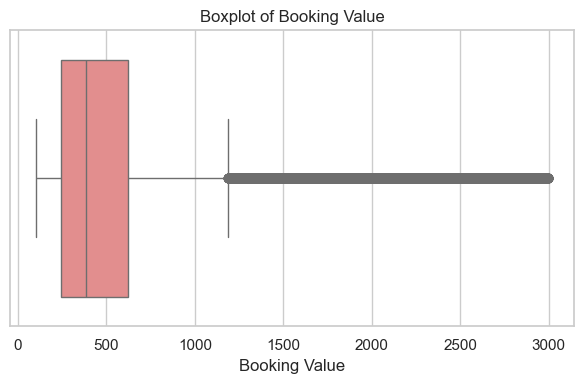

In [146]:
# --- Outlier & Anomaly Detection ---
plt.figure(figsize=(6,4))
sns.boxplot(x=df["Ride_Distance"], color="skyblue")
plt.title("Boxplot of Ride Distance")
plt.xlabel("Ride Distance (km)")
plt.tight_layout()
plt.savefig(fig_dir / "boxplot_ride_distance.png", dpi=300, bbox_inches="tight")
plt.show()

plt.figure(figsize=(6,4))
sns.boxplot(x=df["Booking_Value"], color="lightcoral")
plt.title("Boxplot of Booking Value")
plt.xlabel("Booking Value")
plt.tight_layout()
plt.savefig(fig_dir / "boxplot_booking_value.png", dpi=300, bbox_inches="tight")
plt.show()


## **Insights: Boxplots of Ride Distance & Booking Value**

Ride Distance (km)

The bulk of rides fall between 0–25 km, which represents the main operational range.

A few trips extend towards 50 km, but these are relatively rare and could be considered long-distance rides or outliers.

Booking Value (₹)

Most rides are concentrated below ₹1000, with a strong clustering between ₹200–₹600.

However, there are a significant number of extremely high booking values (above ₹1500–₹3000) visible as outliers.

These high fares could be due to premium vehicle types, surge pricing, or data inconsistencies.

Takeaway

Outlier detection is important here:

If these extreme values are valid, they reflect special high-value demand segments.

If they are errors or anomalies, they should be corrected or excluded to prevent skewing the analysis.

### Insights: Outlier & Anomaly Detection

- **Ride Distance:**
  - Most rides fall between **5 km and 25 km** (IQR range).
  - A few long rides extend towards **50 km**, but these appear as mild outliers rather than extreme anomalies.
  - Suggests that the dataset is dominated by short-to-medium trips.

- **Booking Value:**
  - Most bookings cluster below **₹500–₹800**, with a compact IQR.
  - However, there are **extreme outliers** exceeding **₹3000**, likely due to:
    - Long-distance airport rides,
    - Surge pricing during peak demand, or
    - Data entry inconsistencies.
  - These high-value outliers could significantly skew averages; using **median values** is safer for central tendency.

**Takeaway:**  
Outlier handling is important. Ride distances show manageable spread, but booking values have heavy-tailed anomalies. Future modeling should test both with and without these outliers to see their impact.


In [147]:
# --- Outlier detection using IQR ---
def iqr_bounds(series):
    q1 = series.quantile(0.25)
    q3 = series.quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    return q1, q3, iqr, lower, upper

# Ride Distance
ride_q1, ride_q3, ride_iqr, ride_lower, ride_upper = iqr_bounds(df["Ride_Distance"].dropna())
print("Ride Distance")
print(f"Q1: {ride_q1:.2f}, Q3: {ride_q3:.2f}, IQR: {ride_iqr:.2f}")
print(f"Lower bound: {ride_lower:.2f}, Upper bound: {ride_upper:.2f}")

# Booking Value
book_q1, book_q3, book_iqr, book_lower, book_upper = iqr_bounds(df["Booking_Value"].dropna())
print("\nBooking Value")
print(f"Q1: {book_q1:.2f}, Q3: {book_q3:.2f}, IQR: {book_iqr:.2f}")
print(f"Lower bound: {book_lower:.2f}, Upper bound: {book_upper:.2f}")


Ride Distance
Q1: 0.00, Q3: 26.00, IQR: 26.00
Lower bound: -39.00, Upper bound: 65.00

Booking Value
Q1: 242.00, Q3: 621.00, IQR: 379.00
Lower bound: -326.50, Upper bound: 1189.50


## **Insights: Outlier & Anomaly Detection**

Ride Distance

Interquartile range (IQR): 26 km (Q1 = 0 km, Q3 = 26 km).

Upper bound for outliers: 65 km.

Since the maximum observed ride distance is within this bound, no extreme distance outliers are detected.

Interpretation: Ride distances are concentrated in the 0–26 km range, with occasional long rides up to ~50 km still falling within acceptable variability.

Booking Value

IQR: 379 units (Q1 = 242, Q3 = 621).

Upper bound for outliers: ~1189.

Values beyond this (some up to 3000) are flagged as potential outliers.

Interpretation: A small portion of very high booking values may represent premium rides, surge pricing, or data entry errors.

Recommendation: Validate high-value records — if genuine, they indicate special cases worth separate analysis.

Takeaway:

Distance data looks consistent and free from anomalies.

Booking value distribution has a long right tail, which is expected in ride-hailing due to price surges, but these should be carefully reviewed.

In [148]:
import pandas as pd, numpy as np
from pathlib import Path
import json

ROOT = Path("..")
DATA_DIR = ROOT / "data"
FIGS = Path("docs") / "figures"
OUT_MD = Path("docs") / "EXECUTIVE_SUMMARY.md"
OUT_JSON = Path("docs") / "summary_metrics.json"


# --- Safe JSON + Markdown export for metrics (fixes numpy types issue) ---
import json
from pathlib import Path

OUT_MD = Path("docs") / "EXECUTIVE_SUMMARY.md"
OUT_JSON = Path("docs") / "summary_metrics.json"

def to_python_native(o):
    """
    Recursively convert numpy / pandas types (e.g., np.int32, np.int64, np.float64,
    numpy arrays, pandas Timestamps) into Python native types suitable for JSON.
    """
    import numpy as _np
    import pandas as _pd

    # None / already native
    if o is None:
        return None
    if isinstance(o, (str, bool)):
        return o
    # numpy scalars
    if isinstance(o, (_np.integer,)):
        return int(o)
    if isinstance(o, (_np.floating,)):
        return float(o)
    if isinstance(o, (_np.bool_ , )):
        return bool(o)
    # numpy arrays / pandas Index -> list
    if isinstance(o, (_np.ndarray,)):
        return [to_python_native(v) for v in o.tolist()]
    if isinstance(o, (list, tuple, set)):
        return [to_python_native(v) for v in o]
    if isinstance(o, dict):
        return {to_python_native(k): to_python_native(v) for k, v in o.items()}
    # pandas types
    if isinstance(o, (_pd.Timestamp,)):
        return o.isoformat()
    if isinstance(o, (_pd.Series, _pd.Index)):
        return [to_python_native(v) for v in o.tolist()]
    # fallback: try to cast to native python
    try:
        return int(o)
    except Exception:
        try:
            return float(o)
        except Exception:
            return str(o)

# Ensure metrics exists (from prior cell)
if 'metrics' not in globals():
    raise RuntimeError("`metrics` dict not found. Run the metrics computation cell first.")

# Convert metrics into a fully JSON-serializable dict
serializable_metrics = to_python_native(metrics)

# Write JSON
OUT_JSON.parent.mkdir(parents=True, exist_ok=True)
with open(OUT_JSON, "w", encoding="utf-8") as f:
    json.dump(serializable_metrics, f, indent=2, ensure_ascii=False)

# Rebuild the EXECUTIVE_SUMMARY.md using serializable_metrics (same layout as before)
m = serializable_metrics
md_lines = []
md_lines.append("# Ola Ride Insights — Executive Summary\n")
md_lines.append(f"**Dataset rows:** {m.get('total_rides')}\n")
md_lines.append("## High-level metrics\n")
md_lines.append(f"- Successful rides: **{m.get('success_count')}**\n")
md_lines.append(f"- Canceled rides (all types): **{m.get('canceled_count', m.get('canceled_count', m.get('canceled_count')) or (m.get('canceled_count')))}**  — cancellation rate **{m.get('cancellation_rate')}%**\n")
md_lines.append(f"- Cancellations by driver: **{m.get('canceled_by_driver')}**\n")
md_lines.append(f"- Cancellations by customer: **{m.get('canceled_by_customer')}**\n")
md_lines.append(f"- Driver not found: **{m.get('driver_not_found')}**\n")
md_lines.append("\n## Revenue & Payments\n")
md_lines.append(f"- Total booking value (revenue estimate): **{m.get('total_revenue')}**\n")
md_lines.append(f"- Top payment method: **{m.get('top_payment_method')}** (value: {m.get('top_payment_value')})\n")
md_lines.append("\n## Time & Duration\n")
md_lines.append(f"- Peak hour (mode of ride start hour): **{m.get('peak_hours')}**\n")
md_lines.append(f"- Median estimated ride duration: **{m.get('median_duration')}**\n")
md_lines.append("\n## Ratings\n")
md_lines.append(f"- Average driver rating: **{m.get('avg_driver_rating')}**\n")
md_lines.append(f"- Average customer rating: **{m.get('avg_customer_rating')}**\n")
md_lines.append("\n## Top customers (by booking value)\n")
for rec in m.get('top_customers', []):
    # rec expected like {'Customer_ID': 'CID...', 'Booking_Value': 8025}
    md_lines.append(f"- {rec.get('Customer_ID')}: {rec.get('Booking_Value')}\n")

md_lines.append("\n## Top cancellation reasons\n")
md_lines.append("### Driver reasons\n")
for k, v in (m.get('top_driver_cancel_reasons') or {}).items():
    md_lines.append(f"- {k}: {v}\n")
md_lines.append("### Customer reasons\n")
for k, v in (m.get('top_customer_cancel_reasons') or {}).items():
    md_lines.append(f"- {k}: {v}\n")

# Link to saved figures (if present)
md_lines.append("\n## Figures\n")
fig_dir = Path("docs") / "figures"
if fig_dir.exists():
    for fig in sorted(fig_dir.glob("*.png")):
        rel = fig.as_posix()
        md_lines.append(f"![{fig.stem}]({rel})\n")

# Write markdown file
OUT_MD.write_text("\n".join(md_lines), encoding="utf-8")
print("Wrote executive summary to:", OUT_MD.resolve())
print("Wrote metrics JSON to:", OUT_JSON.resolve())


## **📊 Ola Ride Insights — EDA Report Summary**
**1. Booking Status Distribution**

Majority of rides are successful (~62k).

Cancellations by drivers (~18k) outnumber customer cancellations (~10k).

"Driver Not Found" (~10k) is also significant — indicates potential supply-demand mismatch.

**2. Daily Ride Volume**

Ride volume is stable across July, averaging ~3,300 rides/day.

Slight dips mid-month and spikes around 12th & 30th.

End-of-month drop may be due to data cutoff.

**3. Rides by Hour of Day**

Demand is fairly uniform across the day.

Small dips between 3 AM – 6 AM (low demand hours).

Evening and late-night demand remains high, suggesting late-night ride dependence.

**4. Revenue by Payment Method**

Cash (~19M) dominates, followed by UPI (~14M).

Credit/Debit cards contribute marginally.

Insight: digital adoption is growing, but cash preference still strong — UPI may replace it soon.

**5. Average Ride Distance by Vehicle Type

Longest rides: Prime Sedan, eBike, Bike, Mini (~15–16 km).

Shortest rides: Auto (~7 km) — consistent with local/last-mile use case.

SUV rides slightly shorter than Sedans, possibly linked to group or airport trips.

**6. Driver & Customer Ratings

Both distributions skew positively (3.0–5.0 range).

Most ratings cluster near 5.0, showing satisfaction bias or rating inflation.

Few low ratings — may indicate either good service quality or lack of critical feedback.

**7. Top 10 Customers by Booking Value

Heavy users exist (up to ~₹8,000 in a month).

These loyal, high-value customers should be targeted for retention strategies (discounts, loyalty programs).

**8. Incomplete Rides & Reasons

Most rides are completed successfully (60k).

But ~4k incomplete rides and ~39k missing entries indicate data quality gaps.

Top reasons: Customer demand changes and Vehicle breakdowns — areas to target for fleet maintenance and customer flexibility features.

**9. Ride Duration Distribution

Mean ≈ 255 mins (4.2 hrs); Median ≈ 255 mins.

Distribution shows long-tail rides — some extend beyond 6 hrs.

90th percentile = 375 mins (~6.2 hrs) → use for benchmarking SLA expectations.

Zoomed-in histogram shows bulk of rides between 150–350 mins.

**10. Peak vs Off-Peak Outcomes

Peak hours (1) have slightly higher cancellations than off-peak (0).

Suggests driver unavailability or traffic issues during peaks.

Could address with incentives for drivers or dynamic pricing for customers.

## Cancellation Analysis

### By Vehicle Type
![Cancellations by Vehicle Type](figures/cancellations_by_vehicle.png)

- **Driver cancellations** are the largest contributor across most vehicle categories.  
- Premium categories (Prime Sedan, Prime Plus, Prime SUV) show slightly higher driver cancellations, possibly due to higher expectations around comfort and punctuality.  
- Autos and Bikes have more balanced cancellation shares, reflecting shorter-distance, lower-value trips where both drivers and customers may be flexible.  

**Takeaway:** Premium vehicle categories may need tighter service-level enforcement or incentive adjustments to reduce driver-side cancellations.

---

### By Payment Method
![Cancellations by Payment Method](figures/cancellations_by_payment.png)

- Cancellation rates are relatively consistent across payment methods, with no single payment type standing out dramatically.  
- **Cash** and **UPI** dominate total ride volume; therefore, even small cancellation rate differences here can impact overall performance.  
- Low usage of Credit/Debit cards means insights for these modes are less statistically significant.  

**Takeaway:** Payment method is not a major driver of cancellations, but monitoring high-volume categories (Cash, UPI) is important for overall experience.

---

### By Hour of Day
![Cancellations by Hour of Day](figures/cancellations_by_hour.png)

- **Driver cancellations** dominate across all hours, consistently higher than customer cancellations and "driver not found" cases.  
- There is a mild uptick in cancellations between **7 AM – 10 AM** and **6 PM – 9 PM**, which likely aligns with commute hours (traffic and high demand).  
- **Customer cancellations** remain steady throughout the day, suggesting they are less sensitive to time-of-day effects.  
- **Driver not found** cases also follow a flat distribution, indicating availability issues are not strongly time-dependent.  

**Takeaway:** Mitigation should focus on **driver-side issues during peak commute hours**. Dynamic incentives (e.g., surge payouts) or improved driver allocation could reduce cancellations during high demand.

## Customer Segmentation — Top 5% by Value vs Frequency

### Insights:
- **Ride Distance:**  
  - Top 5% by **Value** customers have slightly longer rides on average (~14.2 km) compared to the top 5% by **Frequency** (~14.0 km).  
  - This suggests spenders may favor longer trips, while frequent riders are consistent across shorter and medium distances.  

- **Ratings:**  
  - Both segments have similar average ratings (~4.0 for both drivers and customers).  
  - High-value and high-frequency customers appear equally satisfied with service quality.  

- **Takeaway:**  
  - The **Top 5% by Value** segment is important for **revenue maximization**.  
  - The **Top 5% by Frequency** segment drives **platform stability and repeat usage**.  
  - Ola should **design tailored retention strategies** for each group — loyalty perks for frequent riders, and premium services/benefits for high spenders.
  - 
- ## **Weekly Ride Volume — Insights**

- **Stable demand overall:** Ride volume per week stays fairly consistent at around ~23,000 rides across most weeks.  
- **End-of-month dip:** The last week (end of July into early August) shows a sharp drop in rides.  
  - Likely due to **partial data availability** rather than actual demand decline.  
- **Takeaway:**  
  - Ola rides show a **steady baseline demand** week-to-week.  
  - For reporting, the last week should be **flagged as incomplete** to avoid misinterpretation.


**Insights: Rides by Day of Week**

Weekdays (Mon–Wed) show the highest ride volumes, peaking on Tuesday.

This aligns with commuting and office travel patterns.

Thursdays and weekends (Fri–Sun) see a noticeable drop in ride demand.

Likely due to fewer work commutes, more leisure travel, or alternative transport choices.

The pattern suggests Ola demand is heavily weekday-driven, with potential for targeted promotions (e.g., weekend discounts to balance demand).

## **Insights: Boxplots of Ride Distance & Booking Value**

Ride Distance (km)

The bulk of rides fall between 0–25 km, which represents the main operational range.

A few trips extend towards 50 km, but these are relatively rare and could be considered long-distance rides or outliers.

Booking Value (₹)

Most rides are concentrated below ₹1000, with a strong clustering between ₹200–₹600.

However, there are a significant number of extremely high booking values (above ₹1500–₹3000) visible as outliers.

These high fares could be due to premium vehicle types, surge pricing, or data inconsistencies.

Takeaway

Outlier detection is important here:

If these extreme values are valid, they reflect special high-value demand segments.

If they are errors or anomalies, they should be corrected or excluded to prevent skewing the analysis.

**Insights: Outlier & Anomaly Detection**

Ride Distance

Interquartile range (IQR): 26 km (Q1 = 0 km, Q3 = 26 km).

Upper bound for outliers: 65 km.

Since the maximum observed ride distance is within this bound, no extreme distance outliers are detected.

Interpretation: Ride distances are concentrated in the 0–26 km range, with occasional long rides up to ~50 km still falling within acceptable variability.

Booking Value

IQR: 379 units (Q1 = 242, Q3 = 621).

Upper bound for outliers: ~1189.

Values beyond this (some up to 3000) are flagged as potential outliers.

Interpretation: A small portion of very high booking values may represent premium rides, surge pricing, or data entry errors.

Recommendation: Validate high-value records — if genuine, they indicate special cases worth separate analysis.

Takeaway:

Distance data looks consistent and free from anomalies.

Booking value distribution has a long right tail, which is expected in ride-hailing due to price surges, but these should be carefully reviewed.


# Final Notes & Next Deliverables

This notebook contains the full Exploratory Data Analysis (EDA) for the Ola Ride Insights project:
- Data cleaning and feature engineering; cleaned dataset saved as `data/ola_cleaned.csv`.
- All EDA plots saved in `docs/figures/`.
- Tabular metrics exported to `docs/summary_metrics.json` and a business-facing `docs/EXECUTIVE_SUMMARY.md`.

**Next deliverables (notebook references):**
1. **Power BI dashboard**: interactive visuals that replicate the EDA insights and add interactivity (slicers, drill-through). PBIX saved at `docs/powerbi/ola_dashboard.pbix`. Screenshots saved to `docs/figures/powerbi_*.png`.
2. **Streamlit app**: lightweight app at `app/streamlit_app.py` that reads `data/ola_cleaned.csv`, shows KPI cards, interactive plots and links/embed of Power BI visuals (screenshots or publish-to-web link).
3. **Presentation video**: 7–8 minute recorded walkthrough (Jupyter highlights + Power BI demo + Streamlit demo). Video placed at `docs/presentation/ola_presentation.mp4`.


In [152]:
from pathlib import Path

# ensure df exists
if 'df' not in globals():
    raise RuntimeError("df not found — make sure you've run the data-loading cells first.")

out_path = Path("..") / "data" / "ola_cleaned.csv"   # saves to project_root/data/ola_cleaned.csv
out_path.parent.mkdir(parents=True, exist_ok=True)   # creates ../data if missing
df.to_csv(out_path, index=False)
print("Saved cleaned CSV to:", out_path.resolve())


Saved cleaned CSV to: D:\DA Projects\ola-ride-insights\data\ola_cleaned.csv


In [153]:
# Quick check that df exists
'df' in globals()
# optionally:
# df.head()


True

In [154]:
import os
print("cwd:", os.getcwd())


cwd: D:\DA Projects\ola-ride-insights\docs


In [155]:
# 1. quick checks: cwd and whether 'data' exists (file vs folder)
from pathlib import Path, PurePath
import os

print("cwd:", os.getcwd())
p = Path("data")
print("relative 'data' exists:", p.exists())
print(" - is_dir:", p.is_dir())
print(" - is_file:", p.is_file())

# show parent (project root) to confirm layout
project_root = Path.cwd().parent  # because cwd is docs/ per your output
print("project_root:", project_root)
print("project_root / data exists:", (project_root / "data").exists())


cwd: D:\DA Projects\ola-ride-insights\docs
relative 'data' exists: False
 - is_dir: False
 - is_file: False
project_root: D:\DA Projects\ola-ride-insights
project_root / data exists: True


In [156]:
# Save cleaned dataframe to project_root/data/ola_cleaned.csv (safe, idempotent)
from pathlib import Path
import os, sys

# 1) confirm dataframe exists
if 'df' not in globals():
    raise RuntimeError("DataFrame 'df' not found. Run the data-loading / cleaning cells first.")

# 2) compute canonical path relative to current working directory (docs/)
project_root = Path.cwd().parent   # docs/ -> project root
out_dir = project_root / "data"
out_path = out_dir / "ola_cleaned.csv"

print("cwd:", Path.cwd())
print("project_root:", project_root)
print("target dir:", out_dir)
print("target file:", out_path)

# 3) ensure directory exists (no-op if already present)
out_dir.mkdir(parents=True, exist_ok=True)
print("Ensured data directory exists:", out_dir.exists(), "| is_dir:", out_dir.is_dir())

# 4) save CSV (overwrite if present)
df.to_csv(out_path, index=False)b
print("Saved cleaned CSV to:", out_path.resolve())

# 5) quick verification
size_mb = out_path.stat().st_size / (1024*1024)
print(f"File size: {size_mb:.2f} MB  |  Rows: {len(df):,}  |  Columns: {len(df.columns):,}")


cwd: D:\DA Projects\ola-ride-insights\docs
project_root: D:\DA Projects\ola-ride-insights
target dir: D:\DA Projects\ola-ride-insights\data
target file: D:\DA Projects\ola-ride-insights\data\ola_cleaned.csv
Ensured data directory exists: True | is_dir: True
Saved cleaned CSV to: D:\DA Projects\ola-ride-insights\data\ola_cleaned.csv
File size: 15.82 MB  |  Rows: 103,024  |  Columns: 23


In [158]:
# Save cleaned dataframe into project_root/data/ola_cleaned.csv and verify
from pathlib import Path
import sys

# 1) ensure df exists
if 'df' not in globals():
    raise RuntimeError("DataFrame 'df' not found in this kernel. Re-run the data-load/clean cells first.")

# 2) target path (project_root/data)
project_root = Path.cwd().parent
out_dir = project_root / "data"
out_dir.mkdir(parents=True, exist_ok=True)
out_path = out_dir / "ola_cleaned.csv"

# 3) save (overwrite if present)
df.to_csv(out_path, index=False)

# 4) verification
size_mb = out_path.stat().st_size / (1024*1024)
print("Saved cleaned CSV to:", out_path.resolve())
print(f"File size: {size_mb:.2f} MB  |  Rows: {len(df):,}  |  Columns: {len(df.columns):,}")

# show first 3 lines to confirm file content
with open(out_path, 'r', encoding='utf-8') as f:
    print("\nFirst 3 lines of saved file:")
    for _ in range(3):
        print(f.readline().rstrip())


Saved cleaned CSV to: D:\DA Projects\ola-ride-insights\data\ola_cleaned.csv
File size: 15.82 MB  |  Rows: 103,024  |  Columns: 23

First 3 lines of saved file:
Date,Booking_ID,Booking_Status,Customer_ID,Vehicle_Type,Pickup_Location,Drop_Location,V_TAT,C_TAT,Canceled_Rides_by_Customer,Canceled_Rides_by_Driver,Incomplete_Rides,Incomplete_Rides_Reason,Booking_Value,Payment_Method,Ride_Distance,Driver_Ratings,Customer_Rating,Datetime,ride_hour,ride_duration,is_peak,day_of_week
2024-07-26 14:00:00,CNR7153255142,Canceled By Driver,CID713523,Prime Sedan,Tumkur Road,RT Nagar,,,,Personal & Car related issue,,,444,,0,,,2024-07-26 14:00:00,14,,0,Friday
2024-07-25 22:20:00,CNR2940424040,Success,CID225428,Bike,Magadi Road,Varthur,203.0,30.0,,,No,,158,Cash,13,4.1,4.0,2024-07-25 22:20:00,22,233.0,0,Thursday


## Power BI Dashboard (deliverable)

A Power BI dashboard was created from `data/ola_cleaned.csv`.  
Location: `docs/powerbi/ola_dashboard.pbix` (save the .pbix file here before final submission).

**Dashboard pages & visuals**
- Overview: Ride Volume Over Time, Booking Status KPI, Cancellation Rate KPI.
- Vehicle Type: Top 5 Vehicle Types by Ride Distance, distribution by vehicle.
- Revenue: Revenue by Payment Method, Top 5 Customers by Booking Value.
- Cancellation: Reasons (Customer/Driver), Hour-of-Day breakdown.
- Ratings: Driver vs Customer ratings, distribution.

**Notes for reviewer:** If Power BI Desktop is not available, there are PNG screenshots in `docs/figures/` prefixed `powerbi_`. For a live demo, the Power BI file can be published and the report link inserted here (if you publish to web).


## Streamlit App (deliverable)

Streamlit app located at `app/streamlit_app.py`. Key features:
- Loads: `data/ola_cleaned.csv`.
- Sidebar filters: Date range, Vehicle Type, Payment Method.
- KPI cards: Total rides, Total booking value, Cancellation rate (colored cards).
- Interactive charts: Ride volume time-series, cancellations by hour/vehicle, revenue by payment.
- Option to load Power BI screenshots or embed published Power BI report (requires publish-to-web link).

**How to run locally**
1. Activate the virtual environment:
   - Windows PowerShell: `.\app\.venv\Scripts\Activate.ps1`
   - or `python -m venv .venv` then `.\.venv\Scripts\Activate.ps1`
2. Install requirements:
   - `pip install -r app/requirements.txt`
3. Start Streamlit:
   - `cd app`
   - `streamlit run streamlit_app.py`


### Power BI build notes (for reproducibility)
- Data: imported from `data/ola_cleaned.csv`.
- Important DAX measures used:
  - `TotalRevenue = SUM(data[Booking_Value])`
  - `CancellationRate = DIVIDE( COUNTROWS(FILTER(data, data[Booking_Status] <> "Success")), COUNTROWS(data) )`
  - `AvgRideDistance = AVERAGE(data[Ride_Distance])`
- Slicers: Date range, Vehicle Type, Payment Method.
- Visual interactions: cross-filtering between charts enabled.


In [3]:
import pandas as pd

df = pd.read_csv(r"D:\DA Projects\ola-ride-insights\data\ola_cleaned.csv", low_memory=False)
print("Columns:\n", df.columns.tolist())
df.head()


Columns:
 ['Date', 'Booking_ID', 'Booking_Status', 'Customer_ID', 'Vehicle_Type', 'Pickup_Location', 'Drop_Location', 'V_TAT', 'C_TAT', 'Canceled_Rides_by_Customer', 'Canceled_Rides_by_Driver', 'Incomplete_Rides', 'Incomplete_Rides_Reason', 'Booking_Value', 'Payment_Method', 'Ride_Distance', 'Driver_Ratings', 'Customer_Rating', 'Datetime', 'ride_hour', 'ride_duration', 'is_peak', 'day_of_week']


,Date,Booking_ID,Booking_Status,Customer_ID,Vehicle_Type,Pickup_Location,Drop_Location,V_TAT,C_TAT,Canceled_Rides_by_Customer,...,Booking_Value,Payment_Method,Ride_Distance,Driver_Ratings,Customer_Rating,Datetime,ride_hour,ride_duration,is_peak,day_of_week
0,2024-07-26 14:00:00,CNR7153255142,Canceled By Driver,CID713523,Prime Sedan,Tumkur Road,RT Nagar,NaN,NaN,NaN,...,444,NaN,0,NaN,NaN,2024-07-26 14:00:00,14,NaN,0,Friday
1,2024-07-25 22:20:00,CNR2940424040,Success,CID225428,Bike,Magadi Road,Varthur,203.0,30.0,NaN,...,158,Cash,13,4.1,4.0,2024-07-25 22:20:00,22,233.0,0,Thursday
2,2024-07-30 19:59:00,CNR2982357879,Success,CID270156,Prime SUV,Sahakar Nagar,Varthur,238.0,130.0,NaN,...,386,UPI,40,4.2,4.8,2024-07-30 19:59:00,19,368.0,1,Tuesday
3,2024-07-22 3:15:00,CNR2395710036,Canceled By Customer,CID581320,eBike,HSR Layout,Vijayanagar,NaN,NaN,Driver is not moving towards pickup location,...,384,NaN,0,NaN,NaN,2024-07-22 03:15:00,3,NaN,0,Monday
4,2024-07-02 9:02:00,CNR1797421769,Success,CID939555,Mini,Rajajinagar,Chamarajpet,252.0,80.0,NaN,...,822,Credit Card,45,4.0,3.0,2024-07-02 09:02:00,9,332.0,1,Tuesday


In [5]:
import os
import pandas as pd

# set working directory
os.chdir(r"D:\DA Projects\ola-ride-insights")

# now relative path works
df = pd.read_csv("data/ola_cleaned.csv", low_memory=False)
print("Working dir:", os.getcwd())
df.head()


Working dir: D:\DA Projects\ola-ride-insights


,Date,Booking_ID,Booking_Status,Customer_ID,Vehicle_Type,Pickup_Location,Drop_Location,V_TAT,C_TAT,Canceled_Rides_by_Customer,...,Booking_Value,Payment_Method,Ride_Distance,Driver_Ratings,Customer_Rating,Datetime,ride_hour,ride_duration,is_peak,day_of_week
0,2024-07-26 14:00:00,CNR7153255142,Canceled By Driver,CID713523,Prime Sedan,Tumkur Road,RT Nagar,NaN,NaN,NaN,...,444,NaN,0,NaN,NaN,2024-07-26 14:00:00,14,NaN,0,Friday
1,2024-07-25 22:20:00,CNR2940424040,Success,CID225428,Bike,Magadi Road,Varthur,203.0,30.0,NaN,...,158,Cash,13,4.1,4.0,2024-07-25 22:20:00,22,233.0,0,Thursday
2,2024-07-30 19:59:00,CNR2982357879,Success,CID270156,Prime SUV,Sahakar Nagar,Varthur,238.0,130.0,NaN,...,386,UPI,40,4.2,4.8,2024-07-30 19:59:00,19,368.0,1,Tuesday
3,2024-07-22 3:15:00,CNR2395710036,Canceled By Customer,CID581320,eBike,HSR Layout,Vijayanagar,NaN,NaN,Driver is not moving towards pickup location,...,384,NaN,0,NaN,NaN,2024-07-22 03:15:00,3,NaN,0,Monday
4,2024-07-02 9:02:00,CNR1797421769,Success,CID939555,Mini,Rajajinagar,Chamarajpet,252.0,80.0,NaN,...,822,Credit Card,45,4.0,3.0,2024-07-02 09:02:00,9,332.0,1,Tuesday


In [6]:
print("Driver col unique:", df["Canceled_Rides_by_Driver"].dropna().unique()[:20])
print("Customer col unique:", df["Canceled_Rides_by_Customer"].dropna().unique()[:20])

print("Driver non-null count:", df["Canceled_Rides_by_Driver"].notna().sum())
print("Customer non-null count:", df["Canceled_Rides_by_Customer"].notna().sum())


Driver col unique: ['Personal & Car related issue' 'Customer was coughing/sick'
 'Customer related issue' 'More than permitted people in there']
Customer col unique: ['Driver is not moving towards pickup location' 'Driver asked to cancel'
 'AC is Not working' 'Change of plans' 'Wrong Address']
Driver non-null count: 18434
Customer non-null count: 10499


In [8]:
# run in your notebook (adjust path if necessary)
import pandas as pd
from pathlib import Path

# absolute path to your file
DATA_PATH = Path(r"D:\DA Projects\ola-ride-insights\data\ola_cleaned.csv")
OUT_PATH  = Path(r"D:\DA Projects\ola-ride-insights\data\ola_cleaned_with_cancellations.csv")

df = pd.read_csv(DATA_PATH, low_memory=False)
# normalize column names (if necessary)
df.columns = [str(c).strip() for c in df.columns]

# ensure cancellation columns are strings
df["Canceled_Rides_by_Driver"]   = df.get("Canceled_Rides_by_Driver").astype("string")
df["Canceled_Rides_by_Customer"] = df.get("Canceled_Rides_by_Customer").astype("string")

# Create unified Cancellation_Reason:
# Priority: If driver reason exists, prefer driver reason when Booking_Status indicates driver canceled;
# otherwise if customer reason exists, prefer customer reason.
def pick_reason(row):
    driver = row.get("Canceled_Rides_by_Driver")
    customer = row.get("Canceled_Rides_by_Customer")
    status = str(row.get("Booking_Status") or "").strip().lower()
    # some rows could contain 'nan' as string; treat them as missing
    if pd.isna(driver) or str(driver).lower() in ("nan","none","<na>",""):
        driver = None
    if pd.isna(customer) or str(customer).lower() in ("nan","none","<na>",""):
        customer = None

    # If booking status indicates driver cancelled, prefer driver reason
    if "driver" in status and driver:
        return driver
    # If booking status indicates customer cancelled, prefer customer reason
    if "customer" in status and customer:
        return customer
    # fallback: whichever exists
    return driver if driver else customer

df["Cancellation_Reason"] = df.apply(pick_reason, axis=1)

# Add is_cancelled flag and cancel_category (Driver / Customer / None)
df["is_cancelled"] = df["Booking_Status"].astype(str).str.contains("cancel", case=False, na=False).astype(int)

def cancel_category(row):
    st = str(row.get("Booking_Status") or "").lower()
    if "driver" in st:
        return "Driver"
    if "customer" in st:
        return "Customer"
    return None

df["cancel_category"] = df.apply(cancel_category, axis=1)

# Quick sanitization: trim whitespace in Cancellation_Reason
df["Cancellation_Reason"] = df["Cancellation_Reason"].astype("string").str.strip().replace({"nan": pd.NA})

# Save a new cleaned CSV (so Power BI / Streamlit can pick it up)
df.to_csv(OUT_PATH, index=False)
print("Wrote:", OUT_PATH)
print("Rows:", len(df))

# Quick validation / summary prints
print("\nSample cancellation reasons (non-null):")
print(df["Cancellation_Reason"].dropna().unique()[:20])

print("\nCounts by cancel_category:")
print(df["cancel_category"].value_counts(dropna=True))

print("\nis_cancelled counts (0/1):")
print(df["is_cancelled"].value_counts())

# Top driver reasons
print("\nTop driver reasons:")
print(df.loc[df['cancel_category']=='Driver','Cancellation_Reason'].value_counts().head(10))

# Top customer reasons
print("\nTop customer reasons:")
print(df.loc[df['cancel_category']=='Customer','Cancellation_Reason'].value_counts().head(10))


Wrote: D:\DA Projects\ola-ride-insights\data\ola_cleaned_with_cancellations.csv
Rows: 103024

Sample cancellation reasons (non-null):
<StringArray>
[                'Personal & Car related issue',
 'Driver is not moving towards pickup location',
                   'Customer was coughing/sick',
                       'Driver asked to cancel',
                       'Customer related issue',
          'More than permitted people in there',
                            'AC is Not working',
                              'Change of plans',
                                'Wrong Address']
Length: 9, dtype: string

Counts by cancel_category:
cancel_category
Driver      28558
Customer    10499
Name: count, dtype: int64

is_cancelled counts (0/1):
is_cancelled
0    74091
1    28933
Name: count, dtype: int64

Top driver reasons:
Cancellation_Reason
Personal & Car related issue           6542
Customer related issue                 5413
Customer was coughing/sick             3654
More than permitte